# Goal of this notebook is to conduct some preliminary analyses that do not require/involve going through the full methodology 

In [1]:
### Importing necessary packages
import pandas as pd
import os
from pathlib import Path
import re
import warnings
#warnings.filterwarnings('ignore')
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates

import cmocean

import cartopy.feature as cfeature
import cartopy.crs as ccrs
import numpy as np
import numpy.linalg as LA
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns
import sklearn
from sklearn.cluster import DBSCAN
import urllib.request
import xarray as xr
import itertools
from scipy.stats import gaussian_kde
from scipy.stats import linregress
from sklearn.neighbors import KernelDensity
from scipy.ndimage import gaussian_filter1d

##Add more as needed
## custom packages
from stormevents_utils import standardize_and_convert_to_utc, build_begin_datetime, load_stormevents_data

In [2]:
# Loading in the data
data_dir = Path("/data1/lepique/stormevents_details/")  

df_scs = load_stormevents_data(data_dir)

Found 76 files
Reading StormEvents_details-ftp_v1.0_d1950_c20250520.csv.gz (year=1950)
Reading StormEvents_details-ftp_v1.0_d1951_c20250520.csv.gz (year=1951)
Reading StormEvents_details-ftp_v1.0_d1952_c20250520.csv.gz (year=1952)
Reading StormEvents_details-ftp_v1.0_d1953_c20250520.csv.gz (year=1953)
Reading StormEvents_details-ftp_v1.0_d1954_c20250520.csv.gz (year=1954)
Reading StormEvents_details-ftp_v1.0_d1955_c20250520.csv.gz (year=1955)
Reading StormEvents_details-ftp_v1.0_d1956_c20250520.csv.gz (year=1956)
Reading StormEvents_details-ftp_v1.0_d1957_c20250520.csv.gz (year=1957)
Reading StormEvents_details-ftp_v1.0_d1958_c20250520.csv.gz (year=1958)
Reading StormEvents_details-ftp_v1.0_d1959_c20250520.csv.gz (year=1959)
Reading StormEvents_details-ftp_v1.0_d1960_c20250520.csv.gz (year=1960)
Reading StormEvents_details-ftp_v1.0_d1961_c20250520.csv.gz (year=1961)
Reading StormEvents_details-ftp_v1.0_d1962_c20250520.csv.gz (year=1962)
Reading StormEvents_details-ftp_v1.0_d1963_c20250

In [3]:
df_scs.head()

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,BEGIN_DT,WINTER_SEASON,SOURCE_FILE_YEAR,BEGIN_DT_UTC
0,195004,28,1445,195004,28,1445,NaN,10096222,OKLAHOMA,40.0,...,-99.20,35.17,-99.20,NaN,NaN,PUB,1950-04-28 14:45:00,1950,1950,1950-04-28 20:45:00+00:00
1,195004,29,1530,195004,29,1530,NaN,10120412,TEXAS,48.0,...,-98.60,31.73,-98.60,NaN,NaN,PUB,1950-04-29 15:30:00,1950,1950,1950-04-29 21:30:00+00:00
2,195007,5,1800,195007,5,1800,NaN,10104927,PENNSYLVANIA,42.0,...,-75.70,40.65,-75.47,NaN,NaN,PUB,1950-07-05 18:00:00,1950,1950,1950-07-05 23:00:00+00:00
3,195007,5,1830,195007,5,1830,NaN,10104928,PENNSYLVANIA,42.0,...,-76.75,NaN,NaN,NaN,NaN,PUB,1950-07-05 18:30:00,1950,1950,1950-07-05 23:30:00+00:00
4,195007,24,1440,195007,24,1440,NaN,10104929,PENNSYLVANIA,42.0,...,-79.68,NaN,NaN,NaN,NaN,PUB,1950-07-24 14:40:00,1950,1950,1950-07-24 19:40:00+00:00


In [3]:
## Subsetting winter months:
winter_season = {12, 1, 2,3}
df_winter_scs = df_scs[df_scs["BEGIN_DT"].dt.month.isin(winter_season)]

warm_season = {4,5,6,7,8}
df_warm_scs = df_scs[df_scs['BEGIN_DT'].dt.month.isin(warm_season)]

In [4]:
df_winter_scs_subset = df_winter_scs[df_winter_scs["WINTER_SEASON"] >= 1996]

In [8]:
df_winter_scs['EVENT_TYPE'].unique()

array(['Tornado', 'Thunderstorm Wind', 'Hail'], dtype=object)

In [4]:
df_winter_scs[df_winter_scs['EVENT_TYPE'] == 'Thunderstorm Wind'].MAGNITUDE.unique()

array([  0. ,  67. ,  68. , 100. ,  50. ,  70. ,  56. ,  53. ,  60. ,
        54. ,  78. ,  63. ,  71. ,  65. ,  80. ,  62. ,  85. ,  84. ,
        74. ,  52. ,  58. ,  57. ,  66. ,  51. ,  55. ,  64. ,  61. ,
        75. ,  59. ,  90. ,  87. ,  83. ,  73. ,  72. ,  82. ,  88. ,
        69. ,  86. ,  98. ,  76. ,  93. ,  47. ,  45. ,  40. ,  44. ,
         nan,  49. ,  48. ,  91. ,  35. ,  43. ,  95. ,  77. , 117. ,
       104. ,  74.4,  60.2,  80.8,  64.1,  51.2,  83.6,  39. ,   5. ,
        37. ,   2. ,  38. ,  81. ,  46. ,  42. ,  41. ,  36. ,  96. ,
        79. ,  30. ,  26. ,  32. ,  33. ,  13. ,  99. ,  92. ,  20. ,
         1. ])

## Decadal plots to compare "hotspots"

In [6]:
decades = [
    ("1996-2005", 1996, 2005),
    ("2006-2015", 2006, 2015),
    ("2016-2025", 2016, 2025)
]

In [7]:
proj = ccrs.LambertConformal(
    central_longitude=-96, central_latitude=39,
    standard_parallels=(33, 45),
)

plate = ccrs.PlateCarree()


event_type = "tornado"   # "hail", "tornado", "wind"
extent = [-130, -65, 23, 50]   # lon_min, lon_max, lat_min, lat_max

# KDE smoothness (in meters since we're in projected coordinates)
bandwidth_m = 150_000  # try 150_000 to 300_000

# Grid for evaluation (in lon/lat, then transformed to proj x/y)
nlon, nlat = 280, 170
lon = np.linspace(extent[0], extent[1], nlon)
lat = np.linspace(extent[2], extent[3], nlat)
LON, LAT = np.meshgrid(lon, lat)

grid_xy = proj.transform_points(plate, LON, LAT)[..., :2]
GX, GY = grid_xy[..., 0], grid_xy[..., 1]
grid_valid = np.isfinite(GX) & np.isfinite(GY)
grid_points = np.column_stack([GX[grid_valid], GY[grid_valid]])

In [8]:
# ----------------------------
# Event mask helper
# ----------------------------
def event_mask(et_series, event_type):
    et = et_series.str.upper().fillna("OTHER")
    e = event_type.lower()
    if e.startswith("tornado"):
        return et.str.contains("TORNADO")
    if e.startswith("hail"):
        return et.str.contains("HAIL")
    return et.str.contains("THUNDERSTORM WIND")


In [9]:
### Running Kernel Density Estimation for each decade
kde_maps = {}

for label, y0, y1 in decades:
    d = df_winter_scs[
        (df_winter_scs["WINTER_SEASON"] >= y0) &
        (df_winter_scs["WINTER_SEASON"] <= y1)
    ].copy()

    d = d[event_mask(d["EVENT_TYPE"], event_type)]
    d = d.dropna(subset=["BEGIN_LAT", "BEGIN_LON"])

    # keep points in plotting extent (just to be sure)
    d = d[
        (d["BEGIN_LON"] >= extent[0]) & (d["BEGIN_LON"] <= extent[1]) &
        (d["BEGIN_LAT"] >= extent[2]) & (d["BEGIN_LAT"] <= extent[3])
    ]

    if d.empty:
        print(f"No {event_type} reports for {label}")
        kde_maps[label] = None
        continue

    pts_xy = proj.transform_points(
        plate,
        d["BEGIN_LON"].to_numpy(),
        d["BEGIN_LAT"].to_numpy()
    )[:, :2]
    pts_xy = pts_xy[np.isfinite(pts_xy).all(axis=1)]

    if len(pts_xy) < 5:
        print(f"Too few points for KDE in {label}")
        kde_maps[label] = None
        continue

    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth_m)
    kde.fit(pts_xy)

    log_dens = np.full(LON.shape, np.nan)
    log_dens[grid_valid] = kde.score_samples(grid_points)
    dens = np.exp(log_dens)

    # Normalize to sum to 1 over map (relative footprint per decade)
    # Area weighting because grid is in lon/lat
    area_w = np.cos(np.deg2rad(LAT))
    total = np.nansum(dens * area_w)
    dens_norm = dens / total if total > 0 else dens

    kde_maps[label] = dens_norm


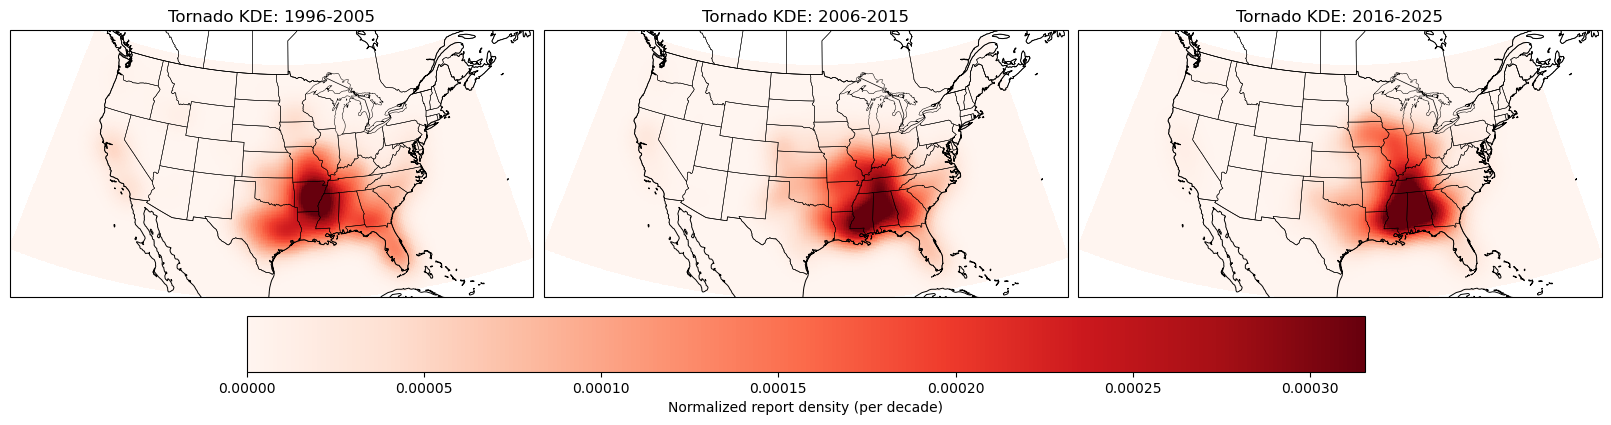

In [10]:
## Make plots
all_vals = np.concatenate([
    m[np.isfinite(m)] for m in kde_maps.values() if m is not None
])
vmax = np.nanpercentile(all_vals, 99)  # robust shared scale

fig, axes = plt.subplots(
    1, 3, figsize=(16, 5),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

for ax, (label, _, _) in zip(axes, decades):
    ax.set_extent(extent, crs=plate)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.35)
    ax.set_title(f"{event_type.title()} KDE: {label}")

    Z = kde_maps[label]
    if Z is None:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                ha="center", va="center")
        continue

    im = ax.pcolormesh(
        LON, LAT, Z,
        transform=plate, shading="auto",
        cmap="Reds", vmin=0, vmax=vmax
    )

cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=0.8, pad=0.04)
cbar.set_label("Normalized report density (per decade)")
#fig.savefig('kde_wind.png', dpi=300)
plt.show()

In [17]:
label

'2016-2025'

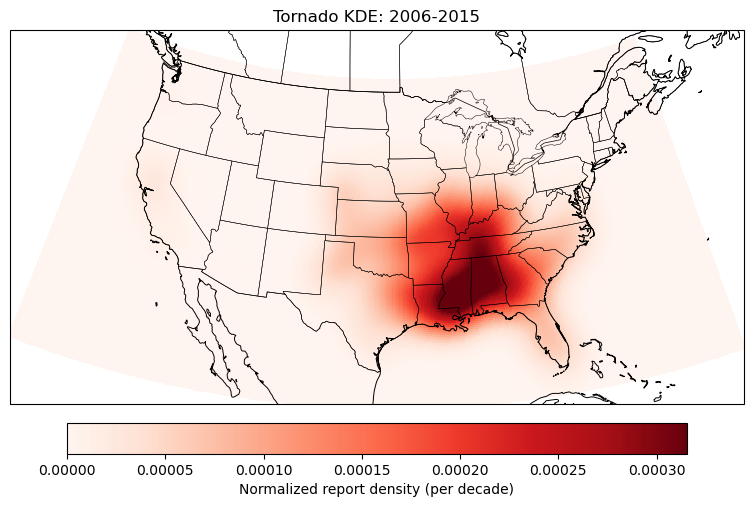

In [25]:
label='2006-2015'
    
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection=proj)

ax.set_extent(extent, crs=plate)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)
ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.35)
ax.set_title(f"{event_type.title()} KDE: {label}")

Z = kde_maps[label]

im = ax.pcolormesh(
    LON, LAT, Z,
    transform=plate, shading="auto",
    cmap="Reds", vmin=0, vmax=vmax
)

cbar = fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.8, pad=0.04)
cbar.set_label("Normalized report density (per decade)")
#fig.savefig('kde_wind.png', dpi=300)
plt.show()


## Cook et al (2017) Type Analysis:

Define "outbreak days" as 24h periods from 6 UTC to 6 UTC where there were at least a threshold number of reports (10, 15, 20?)

ERA5 variables they used for composites:
- 300 hPa gph, U and V wind (lifting mechanism, shear)
- Sea level pressure, U and V wind (lifting mechanism, shear)
- 850 hPa gph, U and V wind (lifting mechanism, shear)
- Lifted Index (instability)
- Precipitable water (moisture)

Reanalysis time closest to the average start times of the individual reports was used to determine the set of atmospheric conditions most representative of the outbreak day (they used NARR, which was available only every 6 hours)

In [9]:
## This function creates a dataframe at the OUTBREAK level (not the report level!)
def identify_outbreak_days(df, min_reports=10, min_hail=None, min_wind=None, min_tor=None):
    """
    Identify 6Z-6Z outbreak days following the method in Cook et al. (2017).
    """

    ## Shift report timestamps so that 6Z is the day boundary
    df = df.copy()
    df['OUTBREAK_DAY'] = (df['BEGIN_DT_UTC'] - pd.Timedelta(hours=6)).dt.date

    ## Compute mean report time within each outbreak day
    mean_times = df.groupby('OUTBREAK_DAY')['BEGIN_DT_UTC'].mean()

    ## Aggregate to daily level
    daily = df.groupby('OUTBREAK_DAY').agg(
        N_REPORTS = ('EVENT_ID', 'count'),
        N_TORN = ('EVENT_TYPE', lambda x: (x == 'Tornado').sum()),
        N_HAIL = ('EVENT_TYPE', lambda x: (x == 'Hail').sum()),
        N_WIND = ('EVENT_TYPE', lambda x: (x == 'Thunderstorm Wind').sum()),
        CENTROID_LAT = ('BEGIN_LAT', 'mean'),
        CENTROID_LON = ('BEGIN_LON', 'mean'),
        WINTER_SEASON = ('WINTER_SEASON', 'first'),
        YEAR = ('YEAR', 'first')
    ).reset_index()

    ## Add back mean time
    daily['MEAN_REPORT_TIME'] = daily['OUTBREAK_DAY'].map(mean_times)
    daily['MEAN_REPORT_TIME'] = daily['MEAN_REPORT_TIME'].dt.round('1h')

    

    ## Apply Threshold

    if min_hail is not None:
        outbreak_days = daily[(daily['N_HAIL'] >= min_hail)].copy()
        outbreak_days['OUTBREAK_DAY'] = pd.to_datetime(outbreak_days['OUTBREAK_DAY'])
    elif min_tor is not None:
        outbreak_days = daily[(daily['N_TORN'] >= min_tor)].copy()
        outbreak_days['OUTBREAK_DAY'] = pd.to_datetime(outbreak_days['OUTBREAK_DAY'])

    elif min_wind is not None:
        outbreak_days = daily[(daily['N_WIND'] >= min_wind)].copy()
        outbreak_days['OUTBREAK_DAY'] = pd.to_datetime(outbreak_days['OUTBREAK_DAY'])
    else:
        outbreak_days = daily[(daily['N_REPORTS'] >= min_reports)].copy()
        outbreak_days['OUTBREAK_DAY'] = pd.to_datetime(outbreak_days['OUTBREAK_DAY'])

    ## Clean sequential index
    outbreak_days = outbreak_days.reset_index(drop=True)
    outbreak_days.index = pd.RangeIndex(start=0, stop=len(outbreak_days), step=1, name="Outbreak")
    
    return outbreak_days

In [6]:
## function to identify exclusively SIGNIFICANT outbreak days: 
def identify_sig_outbreak_days(df, min_reports, min_sig_reports):
    """
    This function is designed to identify outbreak days that included at least one significant tornado report (EF2+),
    and/or one significant hail report (2"+ diameter), and/or one significant wind report (~75 mph)
    """

    ## outbreak day
    df = df.copy()
    df['OUTBREAK_DAY'] = (df['BEGIN_DT_UTC'] - pd.Timedelta(hours=6)).dt.date

    ### flagging individual reports as "significant"
    sig_tornado = (df['EVENT_TYPE'] == 'Tornado') & (df['MAGNITUDE'] >= 2)
    sig_hail = (df['EVENT_TYPE'] == 'Hail') & (df['MAGNITUDE'] >= 2)
    sig_wind = (df['EVENT_TYPE'] == 'Thunderstorm Wind') & (df['MAGNITUDE'] >= 65)

    df['IS_SIG'] = sig_tornado | sig_hail | sig_wind

    ## Compute mean report time within each outbreak day
    mean_times = df.groupby('OUTBREAK_DAY')['BEGIN_DT_UTC'].mean()

    # --- Aggregate to daily level ---
    daily = df.groupby('OUTBREAK_DAY').agg(
        N_REPORTS      = ('EVENT_ID',    'count'),
        N_TORN         = ('EVENT_TYPE',  lambda x: (x == 'Tornado').sum()),
        N_HAIL         = ('EVENT_TYPE',  lambda x: (x == 'Hail').sum()),
        N_WIND         = ('EVENT_TYPE',  lambda x: (x == 'Thunderstorm Wind').sum()),
        N_SIG          = ('IS_SIG',      'sum'),
        N_SIG_TORN     = ('EVENT_TYPE',  lambda x: ((x == 'Tornado') &
                                                    (df.loc[x.index, 'MAGNITUDE'] >= 2)).sum()),
        N_SIG_HAIL     = ('EVENT_TYPE',  lambda x: ((x == 'Hail') &
                                                    (df.loc[x.index, 'MAGNITUDE'] >= 2.0)).sum()),
        N_SIG_WIND     = ('EVENT_TYPE',  lambda x: ((x == 'Thunderstorm Wind') &
                                                    (df.loc[x.index, 'MAGNITUDE'] >= 65)).sum()),
        CENTROID_LAT   = ('BEGIN_LAT',   'mean'),
        CENTROID_LON   = ('BEGIN_LON',   'mean'),
        WINTER_SEASON  = ('WINTER_SEASON', 'first'),
        YEAR           = ('YEAR',        'first'),
    ).reset_index()

    # Map to mean time
    daily['MEAN_REPORT_TIME'] = daily['OUTBREAK_DAY'].map(mean_times).dt.round('1h')

    ## apply thresholds:
    sig_days = daily[
        (daily['N_REPORTS'] >= min_reports) & 
        (daily['N_SIG'] >= min_sig_reports)
        ]

    ## Reset index:
    sig_days = sig_days.reset_index(drop=True)
    sig_days.index = pd.RangeIndex(start=0, stop=len(sig_days), step=1, name="Outbreak")

    return sig_days

In [43]:
warm_subset = df_warm_scs[df_warm_scs["YEAR"] >= 1995]
winter_subset = df_winter_scs[df_winter_scs['WINTER_SEASON'] >=1996]

In [42]:
## For regular outbreaks
winter_outbreak_df = identify_outbreak_days(winter_subset, min_wind=3)
warm_outbreak_df = identify_outbreak_days(warm_subset, min_wind=3)

In [121]:
## for significant outbreaks
sig_winter_outbreak_df = identify_sig_outbreak_days(winter_subset, min_reports=15, min_sig_reports=3)
sig_warm_outbreak_df = identify_sig_outbreak_days(warm_subset, min_reports=15, min_sig_reports=3)

### Basic climatology

In [73]:
winter_outbreak_df.columns

Index(['OUTBREAK_DAY', 'N_REPORTS', 'N_TORN', 'N_HAIL', 'N_WIND',
       'CENTROID_LAT', 'CENTROID_LON', 'WINTER_SEASON', 'YEAR',
       'MEAN_REPORT_TIME'],
      dtype='object')

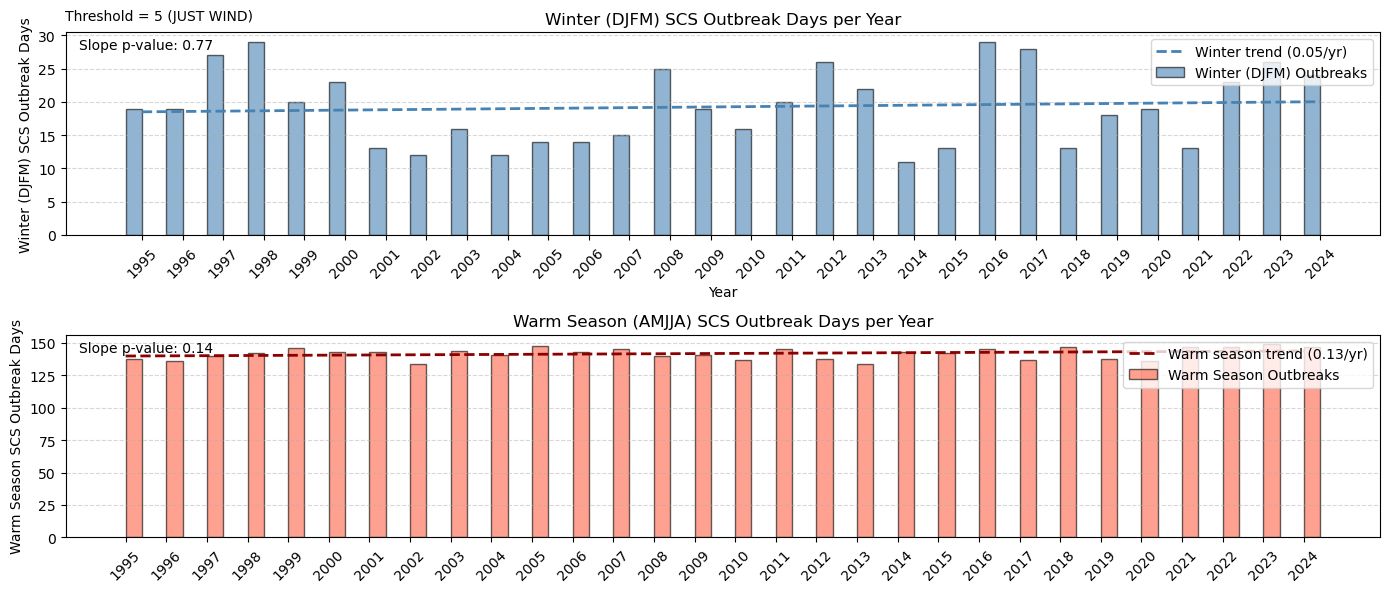

In [43]:
threshold = '5 (JUST WIND)'
warm_counts = (
    warm_outbreak_df.reset_index()
    .groupby('YEAR')['Outbreak']
    .count()
    .sort_index()
)

winter_counts = (
    winter_outbreak_df.reset_index()
    .groupby('WINTER_SEASON')['Outbreak']
    .count()
    .sort_index()
)

# Shift warm season index back by 1 so warm season 1996 aligns with winter season 1995
warm_counts_shifted = warm_counts.copy()
warm_counts_shifted.index = warm_counts_shifted.index - 1

# Now align — winter 1995 will match with warm 1996 (shifted to 1995)
common_years = winter_counts.index.intersection(warm_counts_shifted.index)
winter_aligned = winter_counts.loc[common_years]
warm_aligned = warm_counts_shifted.loc[common_years]

fig, axes = plt.subplots(2,1,figsize=(14, 6))

x = np.arange(len(common_years))
width = 0.4

# Winter bars + trend
axes[0].bar(x - width/2, winter_aligned.values, width=width, color='steelblue', 
        alpha=0.6, edgecolor='black', label='Winter (DJFM) Outbreaks')
z_w = np.polyfit(x, winter_aligned.values, 1)

axes[0].plot(x, np.poly1d(z_w)(x), color='steelblue', linewidth=2, 
         linestyle='--', label=f'Winter trend ({z_w[0]:.2f}/yr)')

## linregress for trend significance
results = linregress(winter_counts.index, winter_counts.values)
axes[0].text(0.01, 0.97, f'Slope p-value: {round(results.pvalue, 2)}',
             ha='left', va='top', transform=axes[0].transAxes)

# Warm season bars + trend
axes[1].bar(x + width/2, warm_aligned.values, width=width, color='tomato', 
        alpha=0.6, edgecolor='black', label='Warm Season Outbreaks')
z_wm = np.polyfit(x, warm_aligned.values, 1)
axes[1].plot(x, np.poly1d(z_wm)(x), color='darkred', linewidth=2, 
         linestyle='--', label=f'Warm season trend ({z_wm[0]:.2f}/yr)')

results2 = linregress(warm_counts.index, warm_counts.values)
axes[1].text(0.01, 0.97, f'Slope p-value: {round(results2.pvalue, 2)}',
             ha='left', va='top', transform=axes[1].transAxes)

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Winter (DJFM) SCS Outbreak Days")
axes[1].set_ylabel("Warm Season SCS Outbreak Days")
#axes[0].tick_params(axis='y', labelcolor='steelblue')
#axes[1].tick_params(axis='y', labelcolor='tomato')

axes[0].set_xticks(x)
axes[1].set_xticks(x)

axes[0].set_xticklabels(common_years, rotation=45)
axes[1].set_xticklabels(common_years, rotation=45)

axes[0].grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.5, zorder=0)


axes[0].legend(loc='upper right')
axes[1].legend(loc='upper right')


axes[0].set_title("Winter (DJFM) SCS Outbreak Days per Year")
axes[1].set_title('Warm Season (AMJJA) SCS Outbreak Days per Year')

fig.text(0.05, 0.98, f'Threshold = {threshold}', 
         fontsize=10, verticalalignment='top')

plt.tight_layout()
#plt.savefig(f'SCS_comparison_{threshold}.png', dpi=300)
plt.show()


In [25]:
winter_counts

WINTER_SEASON
2001     9
2002     6
2003    11
2004     8
2005    13
2006    15
2007     9
2008    20
2009    12
2010     7
2011     6
2012    16
2013    15
2014     6
2015     3
2016    13
2017    16
2018     7
2019     9
2020    10
2021     7
2022    10
2023    12
2024    18
2025     7
Name: Outbreak, dtype: int64

In [76]:
## linear regression of winter SCS outbreaks over time:
results = linregress(winter_counts.index, winter_counts.values)

In [81]:
print(results.slope)
print(results.rvalue)
print(results.pvalue)

0.042001174858037976
0.16368663512671175
0.4052430887566138


In [56]:
### Just looking at DJF:
djf_df_winter_scs = df_scs[df_scs["BEGIN_DT"].dt.month.isin({12,1,2})]
djf_outbreak_df = identify_outbreak_days(djf_df_winter_scs, min_reports=15)

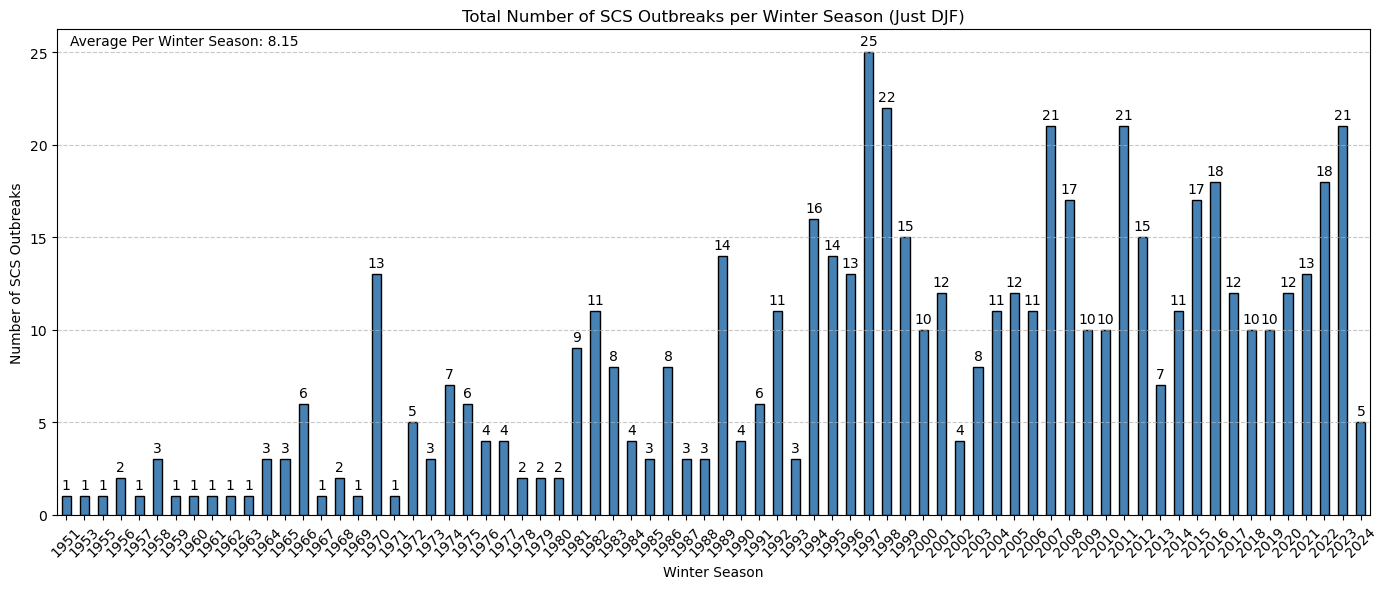

In [60]:
plot_df = djf_outbreak_df.reset_index()

season_counts = (
    plot_df.groupby('WINTER_SEASON')['Outbreak']
    .count()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14,6))
season_counts.plot(kind="bar", ax=ax, color='steelblue', edgecolor='black')

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, color='black', 
                xytext=(0, 3), textcoords='offset points')

ax.set_xlabel("Winter Season")
ax.set_ylabel("Number of SCS Outbreaks")
ax.set_title("Total Number of SCS Outbreaks per Winter Season (Just DJF)")
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax.text(0.01, 0.99, f"Average Per Winter Season: {round(plot_df.groupby('WINTER_SEASON')['Outbreak'].nunique().mean(),2)}", transform = ax.transAxes, ha='left',va='top')
plt.xticks(rotation=45)


plt.tight_layout()
plt.show()

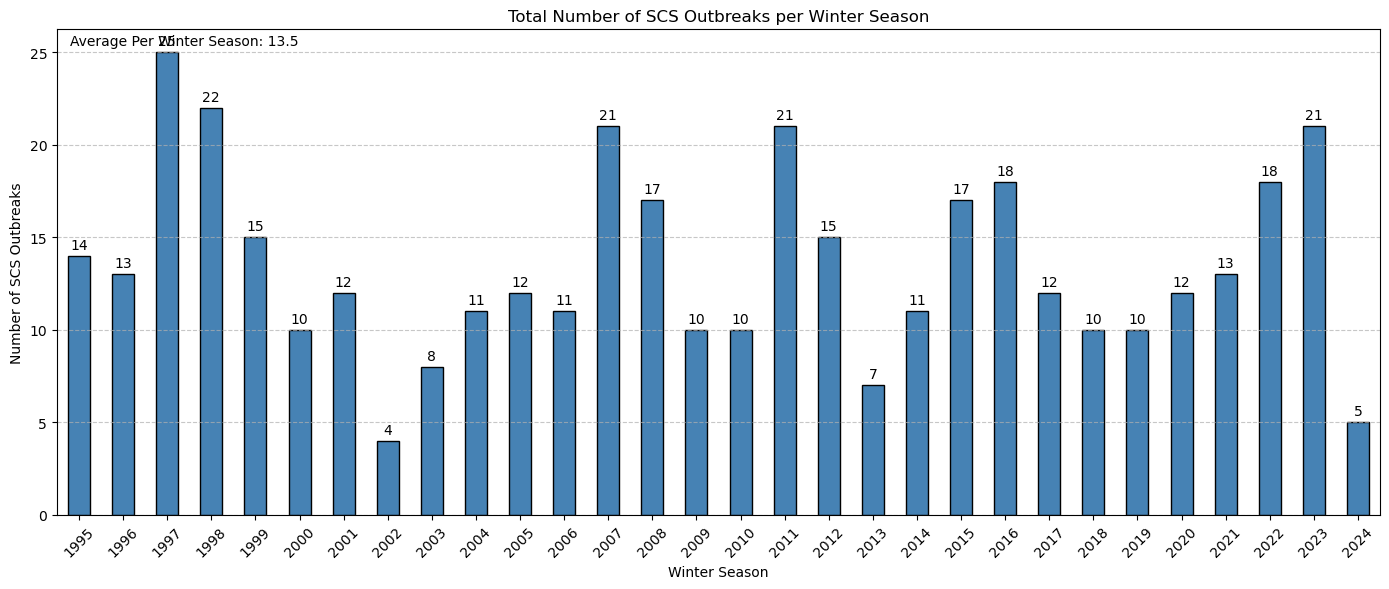

In [63]:
djf_subset = djf_outbreak_df[djf_outbreak_df["WINTER_SEASON"] >= 1995]

plot_df = djf_subset.reset_index()

season_counts = (
    plot_df.groupby('WINTER_SEASON')['Outbreak']
    .count()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14,6))
season_counts.plot(kind="bar", ax=ax, color='steelblue', 
                   edgecolor='black'
                  )

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, color='black', 
                xytext=(0, 3), textcoords='offset points')

ax.set_xlabel("Winter Season")
ax.set_ylabel("Number of SCS Outbreaks")
ax.set_title("Total Number of SCS Outbreaks per Winter Season")
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax.text(0.01, 0.99, f"Average Per Winter Season: {round(plot_df.groupby('WINTER_SEASON')['Outbreak'].nunique().mean(),2)}", transform = ax.transAxes, ha='left',va='top')
plt.xticks(rotation=45)


plt.tight_layout()
plt.show()

###  ERA5 Data

In [22]:
era = xr.open_dataset('/data1/ERA5/Z/Z_2020.grib', engine='cfgrib')

In [36]:
era.latitude

<xarray.DataArray 'latitude' (latitude: 321)> Size: 3kB
array([90.  , 89.75, 89.5 , ..., 10.5 , 10.25, 10.  ], shape=(321,))
Coordinates:
  * latitude  (latitude) float64 3kB 90.0 89.75 89.5 89.25 ... 10.5 10.25 10.0
    number    int64 8B ...
    step      timedelta64[ns] 8B ...
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing

In [63]:
z500 = era['z'].sel(isobaricInhPa = 500)/9.80665  

In [61]:
z500_plot = z500.sel(time="2020-02-06T00:00")

In [66]:
us = z500_plot.sel(
    latitude=slice(55, 20),
    longitude=slice(-130, -60)
)

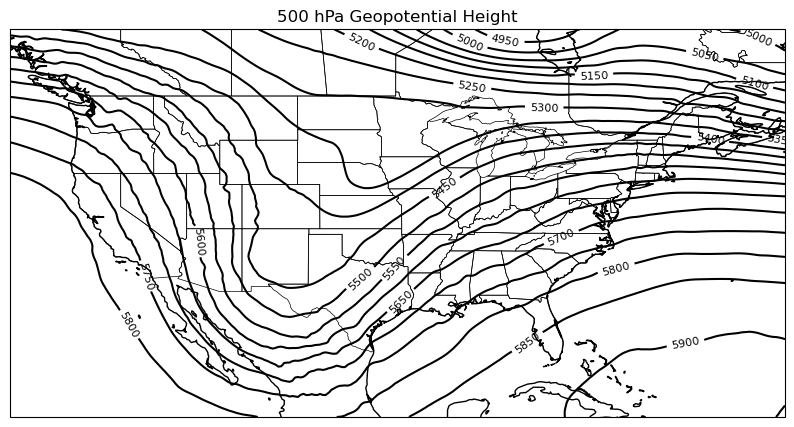

In [79]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

cs = ax.contour(
    us.longitude,
    us.latitude,
    us,
    levels=20,
    colors='black',
    transform=ccrs.PlateCarree()
)
ax.clabel(cs, inline=True, fontsize=8, fmt='%d')


ax.coastlines()
ax.add_feature(cfeature.STATES, linewidth=0.5)

#plt.colorbar(cf, label="Geopotential height (m)")
plt.title("500 hPa Geopotential Height")
plt.show()

## Identifying Top Outbreak Days and Extracting Corresponding ERA5 Data

In [5]:
def identify_top_outbreaks(df, top_n=10):
    """
    Identify top N outbrek days (by total reports)
    Uses 06-06 UTC day definition following Cook et al. 2017.
    """
    ## Shift report timestamps so that 6Z is the day boundary
    df = df.copy()
    df['OUTBREAK_DAY'] = (df['BEGIN_DT_UTC'] - pd.Timedelta(hours=6)).dt.date

    ## Compute mean report time within each outbreak day
    mean_times = df.groupby('OUTBREAK_DAY')['BEGIN_DT_UTC'].mean()

    ## Aggregate to daily level
    daily = df.groupby('OUTBREAK_DAY').agg(
        N_REPORTS = ('EVENT_ID', 'count'),
        N_TORN = ('EVENT_TYPE', lambda x: (x == 'Tornado').sum()),
        N_HAIL = ('EVENT_TYPE', lambda x: (x == 'Hail').sum()),
        N_WIND = ('EVENT_TYPE', lambda x: (x == 'Thunderstorm Wind').sum()),
        CENTROID_LAT = ('BEGIN_LAT', 'mean'),
        CENTROID_LON = ('BEGIN_LON', 'mean'),
        WINTER_SEASON = ('WINTER_SEASON', 'first'),
    ).reset_index()

    ## Add back mean time
    daily['MEAN_REPORT_TIME'] = daily['OUTBREAK_DAY'].map(mean_times)
    daily['MEAN_REPORT_TIME'] = daily['MEAN_REPORT_TIME'].dt.round('1h')

    ## Make sure outbreak day is a datetime object
    daily['OUTBREAK_DAY'] = pd.to_datetime(daily['OUTBREAK_DAY'])

    ## Function to map to nearest ERA5 time (0 or 12 UTC) and add it
    def nearest_era5_time(dt):
        date = dt.normalize()

        t00 = date
        t12 = date + pd.Timedelta(hours=12)
        t24 = date + pd.Timedelta(days=1)
        candidates = [t00,t12,t24]

        return min(candidates, key=lambda x: abs(dt-x))

    daily['ERA5_time'] = daily['MEAN_REPORT_TIME'].apply(nearest_era5_time)
    daily['ERA5_time'] = pd.to_datetime(daily['ERA5_time'])

    ## Select top N per winter season:
    top_outbreaks = (
        daily.sort_values(['WINTER_SEASON','N_REPORTS'], ascending = [True, False])
        .groupby('WINTER_SEASON')
        .head(top_n)
        .copy()
    )

    ## Clean sequential index
    top_outbreaks = top_outbreaks.reset_index(drop=True)
    top_outbreaks.index = pd.RangeIndex(start = 0, stop = len(top_outbreaks), step=1, name='Outbreak')
    
    return top_outbreaks

In [10]:
outbreak_days = identify_top_outbreaks(df_winter_scs_subset, top_n=10)

In [12]:
outbreak_days

,OUTBREAK_DAY,N_REPORTS,N_TORN,N_HAIL,N_WIND,CENTROID_LAT,CENTROID_LON,WINTER_SEASON,MEAN_REPORT_TIME,ERA5_time
Outbreak,,,,,,,,,,
0,1996-03-24,338,5,186,147,34.730845,-95.011197,1996,1996-03-24 22:00:00+00:00,1996-03-25 00:00:00+00:00
1,1996-01-18,206,14,11,181,36.830882,-89.399461,1996,1996-01-18 16:00:00+00:00,1996-01-18 12:00:00+00:00
2,1996-03-06,198,14,101,83,33.284842,-87.827053,1996,1996-03-06 19:00:00+00:00,1996-03-07 00:00:00+00:00
3,1996-03-18,172,25,106,41,32.063413,-88.012575,1996,1996-03-18 21:00:00+00:00,1996-03-19 00:00:00+00:00
4,1996-03-30,153,8,122,23,31.969020,-89.055817,1996,1996-03-30 22:00:00+00:00,1996-03-31 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...
295,2025-03-04,329,40,10,279,32.747056,-93.237802,2025,2025-03-04 17:00:00+00:00,2025-03-04 12:00:00+00:00
296,2025-03-31,275,14,43,218,33.179579,-85.775139,2025,2025-03-31 16:00:00+00:00,2025-03-31 12:00:00+00:00
297,2024-12-28,242,97,21,124,32.098881,-90.522274,2025,2024-12-29 00:00:00+00:00,2024-12-29 00:00:00+00:00


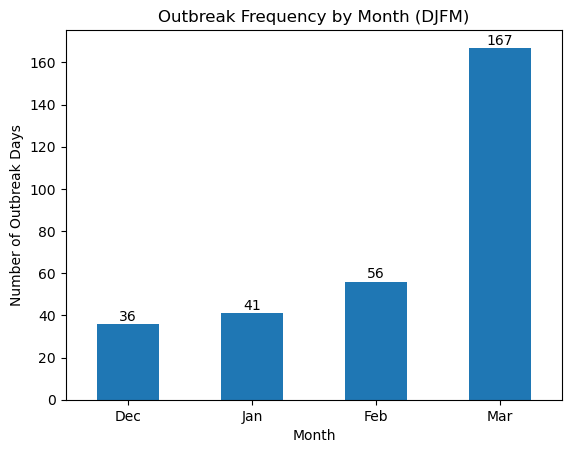

In [13]:
outbreak_days['MONTH_NAME'] = outbreak_days['OUTBREAK_DAY'].dt.strftime('%b')
monthly_counts = outbreak_days['MONTH_NAME'].value_counts()
month_order = ['Dec','Jan','Feb','Mar']
monthly_counts = monthly_counts.reindex(month_order)

ax = monthly_counts.plot(kind='bar')
plt.xlabel('Month')
plt.xticks(rotation=0)

for i, value in enumerate(monthly_counts):
    ax.text(i, value + 0.2, str(value),
            ha='center', va='bottom')

plt.ylabel('Number of Outbreak Days')
plt.title('Outbreak Frequency by Month (DJFM)');

In [14]:
outbreak_days['ERA5_time'].dt.hour.value_counts()

ERA5_time
0     214
12     86
Name: count, dtype: int64

In [7]:
## Define spatial bounding box (general united states)
#lat_min, lat_max = 20,55
#lon_min, lon_max = -130,-60

# Kiefer et al. 2026
#lat_min, lat_max = 10,75
#lon_min, lon_max = -140,-40

# Cook et al 2017: 130° and 67.5°W and 25° and 50°N
lat_min, lat_max = 25,50
lon_min, lon_max = -130,-67.5

In [8]:
## lists to store extracted 500 hPa Z grids here
extracted_grids = []
valid_times = []

In [11]:
## Load in ERA5 data 
outbreak_days['Year'] = outbreak_days['ERA5_time'].dt.year

for year, group in outbreak_days.groupby('Year'):
    file_path = f"/data1/ERA5/Z/Z_{year}.grib"

    if not os.path.exists(file_path):
        print(f"File missing: {file_path}")
        continue

    print(f"Processing year {year}...")

    ds = xr.open_dataset(file_path, engine='cfgrib', 
                         backend_kwargs={'filter_by_keys': {'typeOfLevel': 'isobaricInhPa'}}
                        )
    ## extract the specific times for this year's outbreaks:
    times_to_extract = group['ERA5_time'].values

    ## Select 500 hPa
    try:
        subset = ds['z'].sel(
            time=times_to_extract,
            isobaricInhPa=500,
            latitude=slice(lat_max, lat_min),
            longitude=slice(lon_min, lon_max)
        )

        ## Convert from geopotential to geopotential height
        subset = subset / 9.80665 

        ## Update attributes to avoid later confusion
        subset.attrs['units'] = 'gpm'
        subset.attrs['long_name'] = 'Gepotential Height'
        ## Only load this subset into RAM
        subset = subset.compute()

        extracted_grids.append(subset)
        valid_times.extend(subset.time.values)

    except KeyError as e:
        print(f"Error slicing data for {year}: {e}")

    ds.close()

print('DONE!')

Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...
DONE!


In [12]:
## Concatenate all years into a single 3d DataArray (time, lat, lon)
z_500_all_outbreaks = xr.concat(extracted_grids, dim='time')

In [13]:
print(f"Extracted shape: {z_500_all_outbreaks.shape} (Outbreaks x Lat x Lon)")

Extracted shape: (300, 101, 251) (Outbreaks x Lat x Lon)


In [14]:
z_500_all_outbreaks.coords

Coordinates:
  * time           (time) datetime64[ns] 2kB 1996-03-25 ... 2025-03-05T12:00:00
  * latitude       (latitude) float64 808B 50.0 49.75 49.5 ... 25.5 25.25 25.0
  * longitude      (longitude) float64 2kB -130.0 -129.8 -129.5 ... -67.75 -67.5
    number         int64 8B 0
    step           timedelta64[ns] 8B 00:00:00
    isobaricInhPa  float64 8B 500.0
    valid_time     (time) datetime64[ns] 2kB 1996-03-25 ... 2025-03-05T12:00:00

## EOF Analysis:

### EOFs within outbreaks 

In [75]:
## PREPARE DATA FOR ANALYSIS
X = z_500_all_outbreaks
lat = X['latitude']
lon = X['longitude']
## Flatten lat lon grid into a time x location shape
a,b,c = np.shape(X)
print(a,b,c)
#Y=X.values.reshape(a,b*c)

## remove sample mean
sample_mean = X.mean('time')
X_removemean = X - sample_mean

## Detrend:
#calculates the fit between time and SST (deg=1 for linear, deg=2 for quadratic)
fit_results = X_removemean.polyfit(dim = 'time', deg=1);

#calculate the trend with time
fit_with_time = xr.polyval(X_removemean.time, fit_results);

#subtracts trend from data
X_removemean = X_removemean - fit_with_time['polyfit_coefficients'];

## To later use to regress unweighted anomalies onto PCs:
Y = X_removemean.values.reshape(a,b*c)

## divide by standard deviation
X_stand = X_removemean/(X_removemean.std('time'))
print(np.shape(X_stand.values))

## Cosine weight latitude
X_stand = X_stand*np.sqrt(np.cos(lat*np.pi/180))


240 141 281
(240, 141, 281)


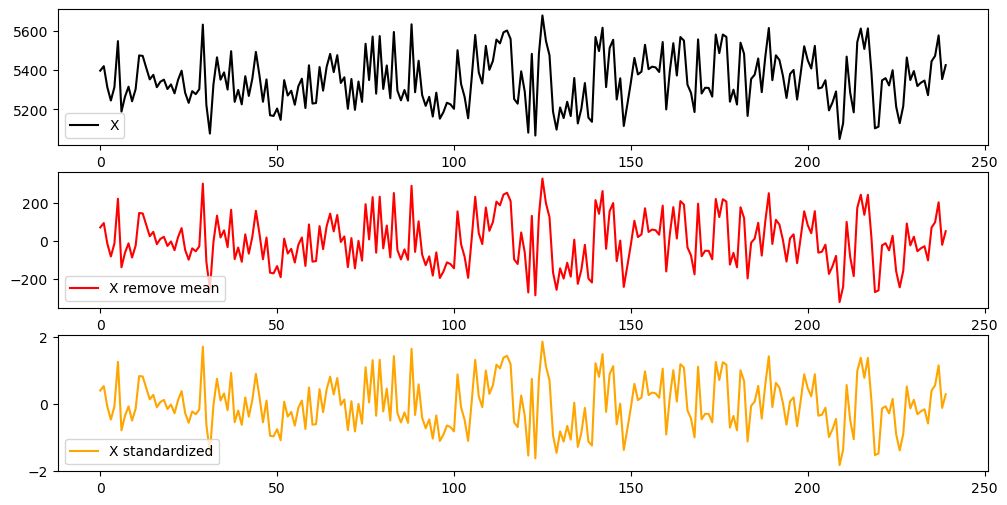

In [76]:
## plot one point to make sure the data have the mean removed and have been standardized

f=plt.figure(figsize=(12,6))
gs=GridSpec(3,1)
plt.subplot(gs[0,0])
plt.plot(X[:,1,1],label='X',color='black')
plt.legend()
plt.subplot(gs[1,0])
plt.plot(X_removemean[:,1,1],label='X remove mean',color='red')
plt.legend()
plt.subplot(gs[2,0])
plt.plot(X_stand[:,1,1],label='X standardized',color='orange')
plt.legend()

In [77]:
## Flatten the lat lon grid into time x location shpe
Y_stand = X_stand.values.reshape(a,b*c)
print(np.shape(Y_stand))

(240, 39621)


In [78]:
## Calculate the EOFS using Singular Value Decomposition
u,s,v = LA.svd(Y_stand, full_matrices=False)

Percent variance explained by EOF1: 20.0 %
Percent variance explained by EOF2: 18.0 %
Percent variance explained by EOF3: 12.0 %
Percent variance explained by EOF4: 12.0 %
Percent variance explained by EOF5: 9.0 %
Percent variance explained by EOF6: 5.0 %
Percent variance explained by EOF7: 5.0 %
Percent variance explained by EOF8: 3.0 %
Percent variance explained by EOF9: 3.0 %
Percent variance explained by EOF10: 2.0 %
Percent variance explained by EOF11: 1.0 %
Percent variance explained by EOF12: 1.0 %


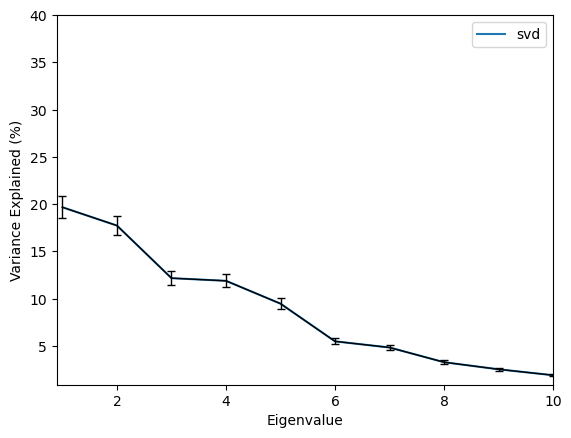

In [79]:
## Plot the eigenvalues

# convert eigenvalues to percent variance explained
pve2 = 100.*np.abs(s**2)/np.sum(np.abs(s**2))
print('Percent variance explained by EOF1:',np.round(pve2[0],0),'%')
print('Percent variance explained by EOF2:',np.round(pve2[1],0),'%')
print('Percent variance explained by EOF3:',np.round(pve2[2],0),'%')
print('Percent variance explained by EOF4:',np.round(pve2[3],0),'%')
print('Percent variance explained by EOF5:',np.round(pve2[4],0),'%')
print('Percent variance explained by EOF6:',np.round(pve2[5],0),'%')
print('Percent variance explained by EOF7:',np.round(pve2[6],0),'%')
print('Percent variance explained by EOF8:',np.round(pve2[7],0),'%')
print('Percent variance explained by EOF9:',np.round(pve2[8],0),'%')
print('Percent variance explained by EOF10:',np.round(pve2[9],0),'%')
print('Percent variance explained by EOF11:',np.round(pve2[10],0),'%')
print('Percent variance explained by EOF12:',np.round(pve2[11],0),'%')



## Hannachi et al. 2007 report observations show EOF1=21% variance, EOF2=13% variance

## Effective sample size calculation:
tseries = np.nanmean(X_stand.values, axis=(1,2))
sigma = np.std(tseries)
mean = np.mean(tseries)
N = len(tseries)
lag = 1

t1_m = tseries[:-lag] - mean
t2_m = tseries[lag:] - mean

alpha = np.correlate(t1_m, t2_m) / ((N-lag) * sigma**2)
alpha = alpha[0]
Nstar = ((1-alpha)/(1+alpha)) * N

eb = pve2 * np.sqrt(2/Nstar)
                     

f=plt.figure()
x = np.arange(1,len(pve2)+1)
plt.plot(x,pve2,label='svd')
plt.errorbar(
    x,
    pve2,
    yerr = eb/2,
    xerr=None,
    linewidth=1,
    color='black',
    capsize=3
)

plt.ylim([0.9,40])
plt.xlim([0.9,10])
plt.ylabel('Variance Explained (%)')
plt.xlabel('Eigenvalue')
plt.legend();


In [80]:
# select an EOF
eof_num=1

# Find the eigenvector (e1) associated with "eof_num" from the SVD method
print(np.shape(v),np.shape(s),np.shape(u))
e1 = (v[eof_num-1,:]).reshape(b,c)
print(np.shape(e1))

# Calculate the principal component (z1) associated with "eof_num" from the SVD method
z1 = u[:,eof_num-1]*(s[eof_num-1])
## standardize it
z1 = (z1-np.mean(z1))/np.std(z1)  
print(np.shape(z1))

# select an EOF
eof_num=2

# Find the eigenvector (e1) associated with "eof_num" from the SVD method
e2 = (v[eof_num-1,:]).reshape(b,c)
print(np.shape(e1))

# Calculate the principal component (z1) associated with "eof_num" from the SVD method
z2 = u[:,eof_num-1]*(s[eof_num-1])
## standardize it
z2 = (z2-np.mean(z2))/np.std(z2)  
print(np.shape(z2))

# select an EOF
eof_num=3

# Find the eigenvector (e1) associated with "eof_num" from the SVD method
e3 = (v[eof_num-1,:]).reshape(b,c)
print(np.shape(e3))

# Calculate the principal component (z1) associated with "eof_num" from the SVD method
z3 = u[:,eof_num-1]*(s[eof_num-1])
## standardize it
z3 = (z3-np.mean(z3))/np.std(z3)  
print(np.shape(z3))


(240, 39621) (240,) (240, 240)
(141, 281)
(240,)
(141, 281)
(240,)
(141, 281)
(240,)


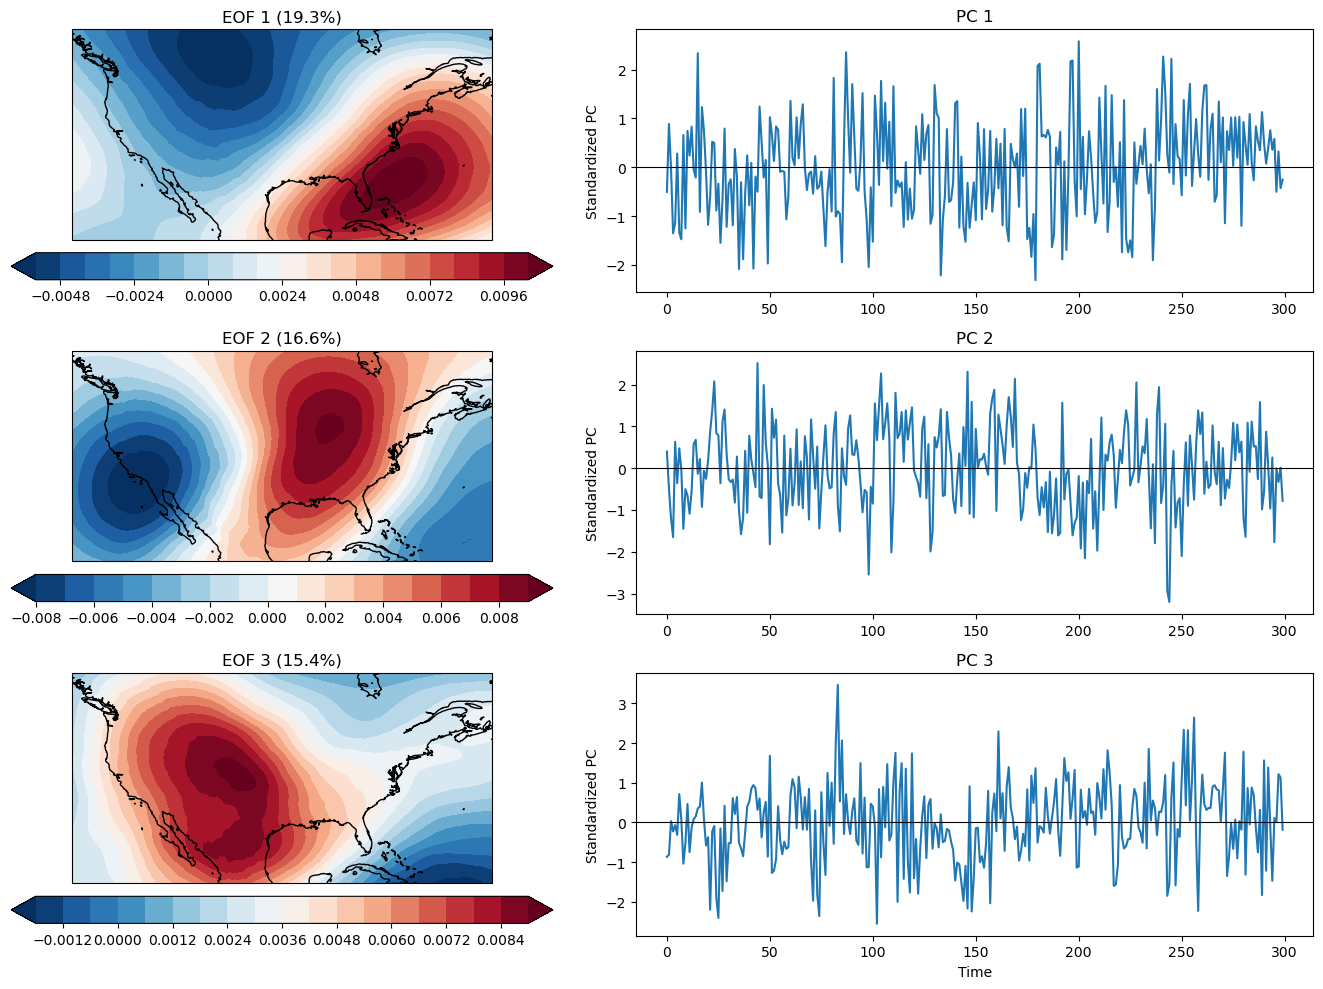

In [20]:
## Plot the first 3 EOFs and the associated PCs

fig = plt.figure(figsize=(14,10))

# EOF 1

ax1 = plt.subplot(3,2,1, projection=ccrs.PlateCarree())

cf1 = ax1.contourf(
    lon,
    lat,
    e1,
    levels=21,
    cmap='RdBu_r',
    extend='both',
    transform=ccrs.PlateCarree()
)

ax1.coastlines()
ax1.set_title(f'EOF 1 ({pve2[0]:.1f}%)')

plt.colorbar(cf1, ax=ax1,
             orientation='horizontal',
             pad=0.05, shrink=0.8)

# PC1
ax2 = plt.subplot(3,2,2)

ax2.plot(z1)
ax2.axhline(0,color='k',linewidth=0.8)

ax2.set_title('PC 1')
ax2.set_ylabel('Standardized PC')

# EOF 2

ax3 = plt.subplot(3,2,3, projection=ccrs.PlateCarree())

cf2 = ax3.contourf(
    lon,
    lat,
    e2,
    levels=21,
    cmap='RdBu_r',
    extend='both',
    transform=ccrs.PlateCarree()
)

ax3.coastlines()
ax3.set_title(f'EOF 2 ({pve2[1]:.1f}%)')

plt.colorbar(cf2, ax=ax3,
             orientation='horizontal',
             pad=0.05, shrink=0.8)

# PC2
ax4 = plt.subplot(3,2,4)

ax4.plot(z2)
ax4.axhline(0,color='k',linewidth=0.8)

ax4.set_title('PC 2')
ax4.set_ylabel('Standardized PC')

# EOF 3

ax5 = plt.subplot(3,2,5, projection=ccrs.PlateCarree())

cf3 = ax5.contourf(
    lon,
    lat,
    e3,
    levels=21,
    cmap='RdBu_r',
    extend='both',
    transform=ccrs.PlateCarree()
)

ax5.coastlines()
ax5.set_title(f'EOF 3 ({pve2[2]:.1f}%)')

plt.colorbar(cf3, ax=ax5,
             orientation='horizontal',
             pad=0.05, shrink=0.8)

# PC3
ax6 = plt.subplot(3,2,6)

ax6.plot(z3)
ax6.axhline(0,color='k',linewidth=0.8)

ax6.set_title('PC 3')
ax6.set_ylabel('Standardized PC')
ax6.set_xlabel('Time')

plt.tight_layout()

In [21]:
## Regress the unweighed data onto standardized PCs

In [81]:
# calculate d for plotting in physical units, not standardized/weighted units.
## d1 is in physical units (in this case degrees) and denotes the anomaly associated with 1 standard deviation
## of z1 (principal component, time variation in this case)

d1 = (1./np.size(Y, axis=0))*np.dot(np.transpose(z1),Y)
d1 = d1.reshape(b,c)

d2 = (1./np.size(Y,axis=0)) * \
     np.dot(np.transpose(z2), Y)

d2 = d2.reshape(b,c)


d3 = (1./np.size(Y,axis=0)) * \
     np.dot(np.transpose(z3), Y)

d3 = d3.reshape(b,c)

In [23]:
Y.shape

(300, 39621)

In [24]:
d1.shape

(141, 281)

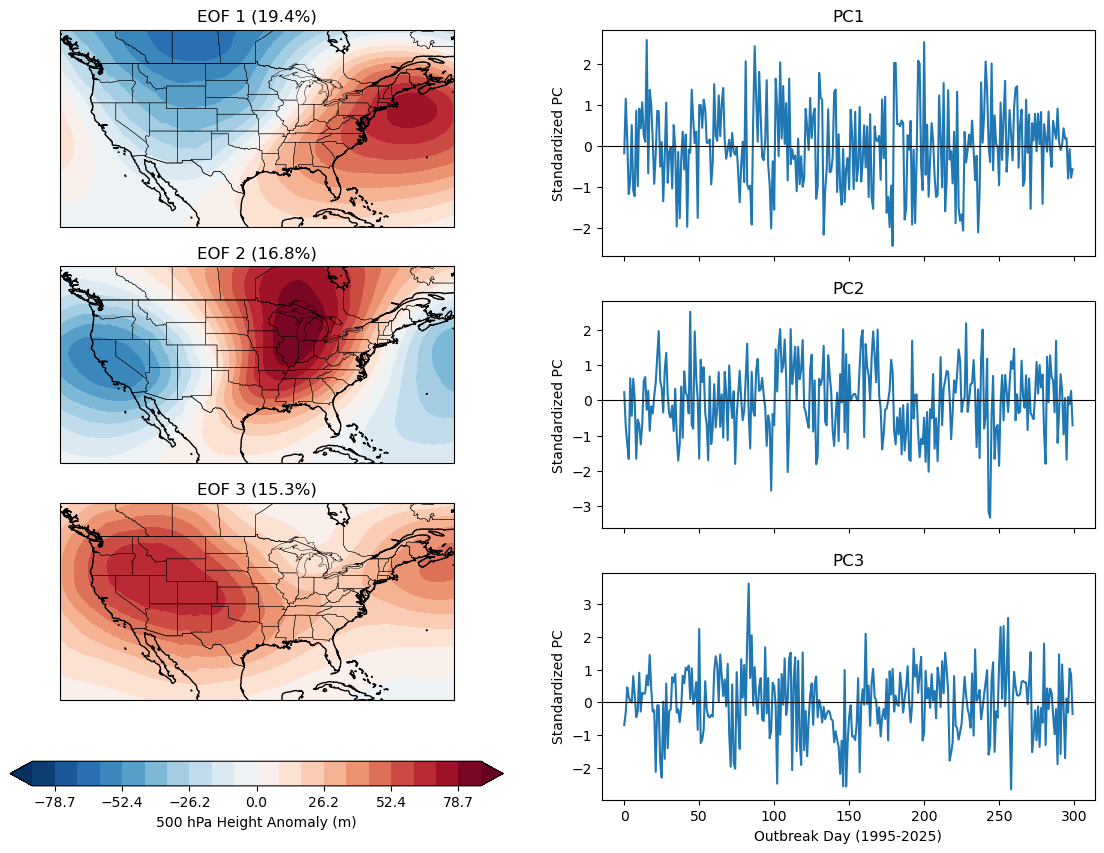

In [41]:
fig = plt.figure(figsize=(14,10))

# Use common contour levels for all panels

vmax = np.max(np.abs([d1,d2]))

levels = np.linspace(-vmax, vmax, 21)

# REGRESSION MAP 1

ax1 = plt.subplot(3,2,1,
                  projection=ccrs.PlateCarree())

cf1 = ax1.contourf(
    lon,
    lat,
    d1,
    levels=levels,
    cmap='RdBu_r',
    extend='both',
    transform=ccrs.PlateCarree()
)

ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax1.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='black')

ax1.set_title(f'EOF 1 ({pve2[0]:.1f}%)')

# plt.colorbar(
#     cf1,
#     ax=ax1,
#     orientation='horizontal',
#     pad=0.05,
#     shrink=0.8,
#     label='meters'
# )

# PC1
ax2 = plt.subplot(3,2,2)

ax2.plot(z1)

ax2.axhline(0,
            color='k',
            linewidth=0.8)

ax2.set_title('PC1')
ax2.set_ylabel('Standardized PC')
ax2.set_xticklabels([])


# REGRESSION MAP 2

ax3 = plt.subplot(3,2,3,
                  projection=ccrs.PlateCarree())

cf2 = ax3.contourf(
    lon,
    lat,
    d2,
    levels=levels,
    cmap='RdBu_r',
    extend='both',
    transform=ccrs.PlateCarree()
)

ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax3.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='black')

ax3.set_title(f'EOF 2 ({pve2[1]:.1f}%)')

# plt.colorbar(
#     cf2,
#     ax=ax3,
#     orientation='horizontal',
#     pad=0.05,
#     shrink=0.8,
#     label='meters'
# )

# PC2
ax4 = plt.subplot(3,2,4)

ax4.plot(z2)

ax4.axhline(0,
            color='k',
            linewidth=0.8)

ax4.set_title('PC2')
ax4.set_ylabel('Standardized PC')
ax4.set_xticklabels([])


# REGRESSION MAP 3

ax5 = plt.subplot(3,2,5,
                  projection=ccrs.PlateCarree())

cf3 = ax5.contourf(
    lon,
    lat,
    d3,
    levels=levels,
    cmap='RdBu_r',
    extend='both',
    transform=ccrs.PlateCarree()
)

ax5.coastlines()
ax5.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax5.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='black')

ax5.set_title(f'EOF 3 ({pve2[2]:.1f}%)')

# plt.colorbar(
#     cf3,
#     ax=ax5,
#     orientation='horizontal',
#     pad=0.05,
#     shrink=0.8,
#     label='meters'
# )

# PC3

ax6 = plt.subplot(3,2,6)

ax6.plot(z3)

ax6.axhline(0,
            color='k',
            linewidth=0.8)

ax6.set_title('PC3')
ax6.set_ylabel('Standardized PC')
ax6.set_xlabel('Outbreak Day (1995-2025)')

cbar = fig.colorbar(
    cf3,
    ax=[ax1,ax3, ax5],
    orientation='horizontal',
    pad=0.08,
    fraction=0.05
)
cbar.set_label('500 hPa Height Anomaly (m)')

#plt.tight_layout()
fig.savefig('EOFs_DJF_outbreak_days', dpi=200)
plt.show()
plt.close()

### EOFs for ALL ERA5 data for comparison purposes

In [84]:
## Load in ERA5 data

all_djfm_grids=[]
all_djfm_times=[]

for year in range(1995,2026):
    file_path = f"/data1/ERA5/Z/Z_{year}.grib"

    if not os.path.exists(file_path):
        print(f"File missing: {file_path}")
        continue

    print(f"Processing year {year}...")

    #load in dataset
    ds = xr.open_dataset(file_path, engine='cfgrib', 
                         backend_kwargs={'filter_by_keys': {'typeOfLevel': 'isobaricInhPa'}}
                        )
    ## extract 500 hPa for only DJFM and 0 UTC:
    try:
        is_djfm = ds['time'].dt.month.isin([12,1,2,3])
        is_00z = ds['time'].dt.hour == 0

        ## Apply mask and spatial slice
        subset = ds['z'].isel(time=(is_djfm & is_00z)).sel(
            isobaricInhPa=500,
            latitude=slice(lat_max, lat_min),
            longitude=slice(lon_min, lon_max)
        )
            

        ## Convert from geopotential to geopotential height
        subset = subset / 9.80665 

        ## Update attributes to avoid later confusion
        subset.attrs['units'] = 'gpm'
        subset.attrs['long_name'] = 'Gepotential Height'
        ## Only load this subset into RAM
        subset = subset.compute()

        all_djfm_grids.append(subset)
        all_djfm_times.extend(subset.time.values)

    except KeyError as e:
        print(f"Error slicing data for {year}: {e}")

    ds.close()

print('DONE!')

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...
DONE!


In [85]:
## Concatenate and rechape:
z_500_all_djfm = xr.concat(all_djfm_grids, dim='time')
print(f"Extracted shape: {z_500_all_djfm.shape} (Days x Lat x Lon)")

Extracted shape: (2798, 141, 281) (Days x Lat x Lon)


In [44]:
## PREPARE DATA FOR ANALYSIS
X_new = z_500_all_djfm
lat_new = X_new['latitude']
lon_new = X_new['longitude']
## Flatten lat lon grid into a time x location shape
a_new,b_new,c_new = np.shape(X_new)
print(a_new,b_new,c_new)
#Y=X.values.reshape(a,b*c)

## remove sample mean
sample_mean_new = X_new.mean('time')

X_removemean_new = X_new - sample_mean_new

## Detrend:
#calculates the fit between time and SST (deg=1 for linear, deg=2 for quadratic)
fit_results = X_removemean_new.polyfit(dim = 'time', deg=1);

#calculate the trend with time
fit_with_time = xr.polyval(X_removemean_new.time, fit_results);

#subtracts trend from data
X_removemean_new = X_removemean_new - fit_with_time['polyfit_coefficients'];


## To later use to regress unweighted anomalies onto PCs:
Y_new = X_removemean_new.values.reshape(a_new,b_new*c_new)

## divide by standard deviation
X_stand_new = X_removemean_new/(X_removemean_new.std('time'))
print(np.shape(X_stand_new.values))

## Cosine weight latitude
X_stand_new = X_stand_new*np.sqrt(np.cos(lat_new*np.pi/180))

3759 141 281
(3759, 141, 281)


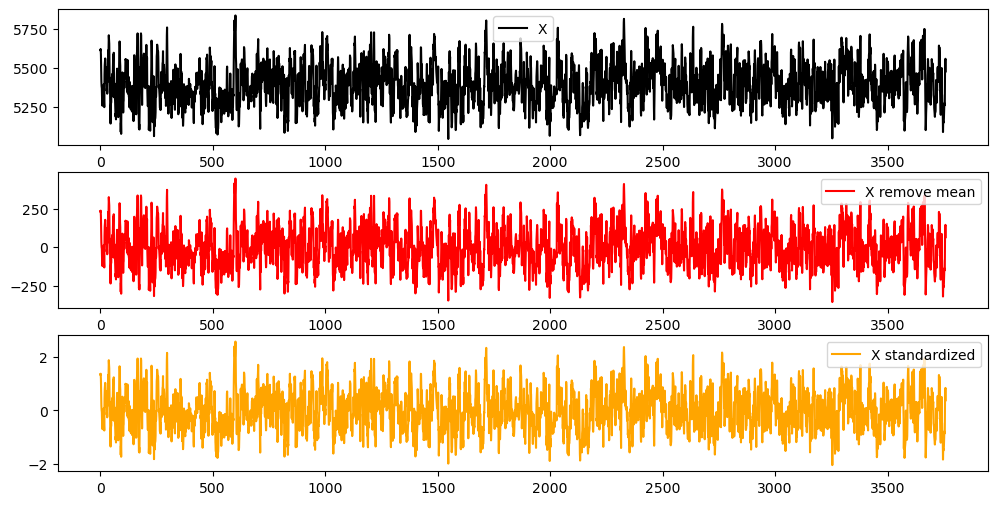

In [45]:
## plot one point to make sure the data have the mean removed and have been standardized

f=plt.figure(figsize=(12,6))
gs=GridSpec(3,1)
plt.subplot(gs[0,0])
plt.plot(X_new[:,1,1],label='X',color='black')
plt.legend()
plt.subplot(gs[1,0])
plt.plot(X_removemean_new[:,1,1],label='X remove mean',color='red')
plt.legend()
plt.subplot(gs[2,0])
plt.plot(X_stand_new[:,1,1],label='X standardized',color='orange')
plt.legend()

In [46]:
## Flatten the lat lon grid into time x location shpe
Y_stand_new = X_stand_new.values.reshape(a_new,b_new*c_new)
print(np.shape(Y_stand_new))

(3759, 39621)


In [47]:
## Calculate the EOFS using Singular Value Decomposition
u_new,s_new,v_new = LA.svd(Y_stand_new, full_matrices=False)

Percent variance explained by EOF1: 21.0 %
Percent variance explained by EOF2: 16.0 %
Percent variance explained by EOF3: 14.0 %


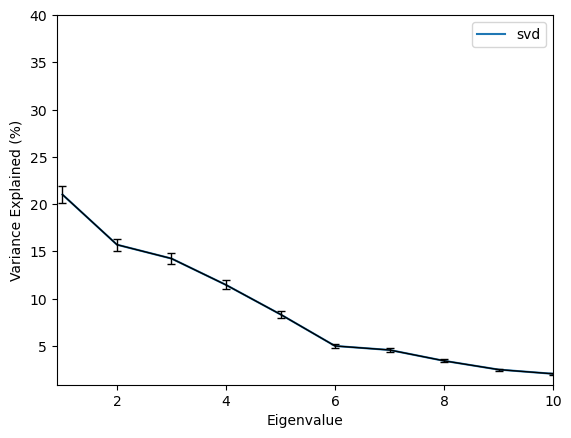

In [82]:
## Plot the eigenvalues

# convert eigenvalues to percent variance explained
pve2_new = 100.*np.abs(s_new**2)/np.sum(np.abs(s_new**2))
print('Percent variance explained by EOF1:',np.round(pve2_new[0],0),'%')
print('Percent variance explained by EOF2:',np.round(pve2_new[1],0),'%')
print('Percent variance explained by EOF3:',np.round(pve2_new[2],0),'%')

## Hannachi et al. 2007 report observations show EOF1=21% variance, EOF2=13% variance

## Effective sample size calculation:
tseries_new = np.nanmean(X_stand_new.values, axis=(1,2))
sigma_new = np.std(tseries_new)
mean_new = np.mean(tseries_new)
N_new = len(tseries_new)
lag = 1

t1_m_new = tseries_new[:-lag] - mean_new
t2_m_new = tseries_new[lag:] - mean_new

alpha_new = np.correlate(t1_m_new, t2_m_new) / ((N_new-lag) * sigma_new**2)
alpha_new = alpha_new[0]
Nstar_new = ((1-alpha_new)/(1+alpha_new)) * N_new

eb_new = pve2_new * np.sqrt(2/Nstar_new)
                     

f=plt.figure()
x_new = np.arange(1,len(pve2_new)+1)
plt.plot(x_new,pve2_new,label='svd')
plt.errorbar(
    x_new,
    pve2_new,
    yerr = eb_new/2,
    xerr=None,
    linewidth=1,
    color='black',
    capsize=3
)

plt.ylim([0.9,40])
plt.xlim([0.9,10])
plt.ylabel('Variance Explained (%)')
plt.xlabel('Eigenvalue')
plt.legend()
#plt.savefig('eigenvalues_climo.png')

In [49]:
# select an EOF
eof_num=1

# Find the eigenvector (e1) associated with "eof_num" from the SVD method
print(np.shape(v_new),np.shape(s_new),np.shape(u_new))
e1_new = (v_new[eof_num-1,:]).reshape(b_new,c_new)
print(np.shape(e1_new))

# Calculate the principal component (z1) associated with "eof_num" from the SVD method
z1_new = u_new[:,eof_num-1]*(s_new[eof_num-1])
## standardize it
z1_new = (z1_new-np.mean(z1_new))/np.std(z1_new)  
print(np.shape(z1_new))

# select an EOF
eof_num=2

# Find the eigenvector (e1) associated with "eof_num" from the SVD method
e2_new = (v_new[eof_num-1,:]).reshape(b_new,c_new)
print(np.shape(e2_new))

# Calculate the principal component (z1) associated with "eof_num" from the SVD method
z2_new = u_new[:,eof_num-1]*(s_new[eof_num-1])
## standardize it
z2_new = (z2_new-np.mean(z2_new))/np.std(z2_new)  
print(np.shape(z2_new))

# select an EOF
eof_num=3

# Find the eigenvector (e1) associated with "eof_num" from the SVD method
e3_new = (v_new[eof_num-1,:]).reshape(b_new,c_new)
print(np.shape(e3_new))

# Calculate the principal component (z1) associated with "eof_num" from the SVD method
z3_new = u_new[:,eof_num-1]*(s_new[eof_num-1])
## standardize it
z3_new = (z3_new-np.mean(z3_new))/np.std(z3_new)  
print(np.shape(z3_new))


(3759, 39621) (3759,) (3759, 3759)
(141, 281)
(3759,)
(141, 281)
(3759,)
(141, 281)
(3759,)


In [50]:
# calculate d for plotting in physical units, not standardized/weighted units.
## d1 is in physical units (in this case degrees) and denotes the anomaly associated with 1 standard deviation
## of z1 (principal component, time variation in this case)

d1_new = (1./np.size(Y_new, axis=0))*np.dot(np.transpose(z1_new),Y_new)
d1_new = d1_new.reshape(b_new,c_new)

d2_new = (1./np.size(Y_new,axis=0)) * \
     np.dot(np.transpose(z2_new), Y_new)

d2_new = d2_new.reshape(b_new,c_new)


d3_new = (1./np.size(Y_new,axis=0)) * \
     np.dot(np.transpose(z3_new), Y_new)

d3_new = d3_new.reshape(b_new,c_new)

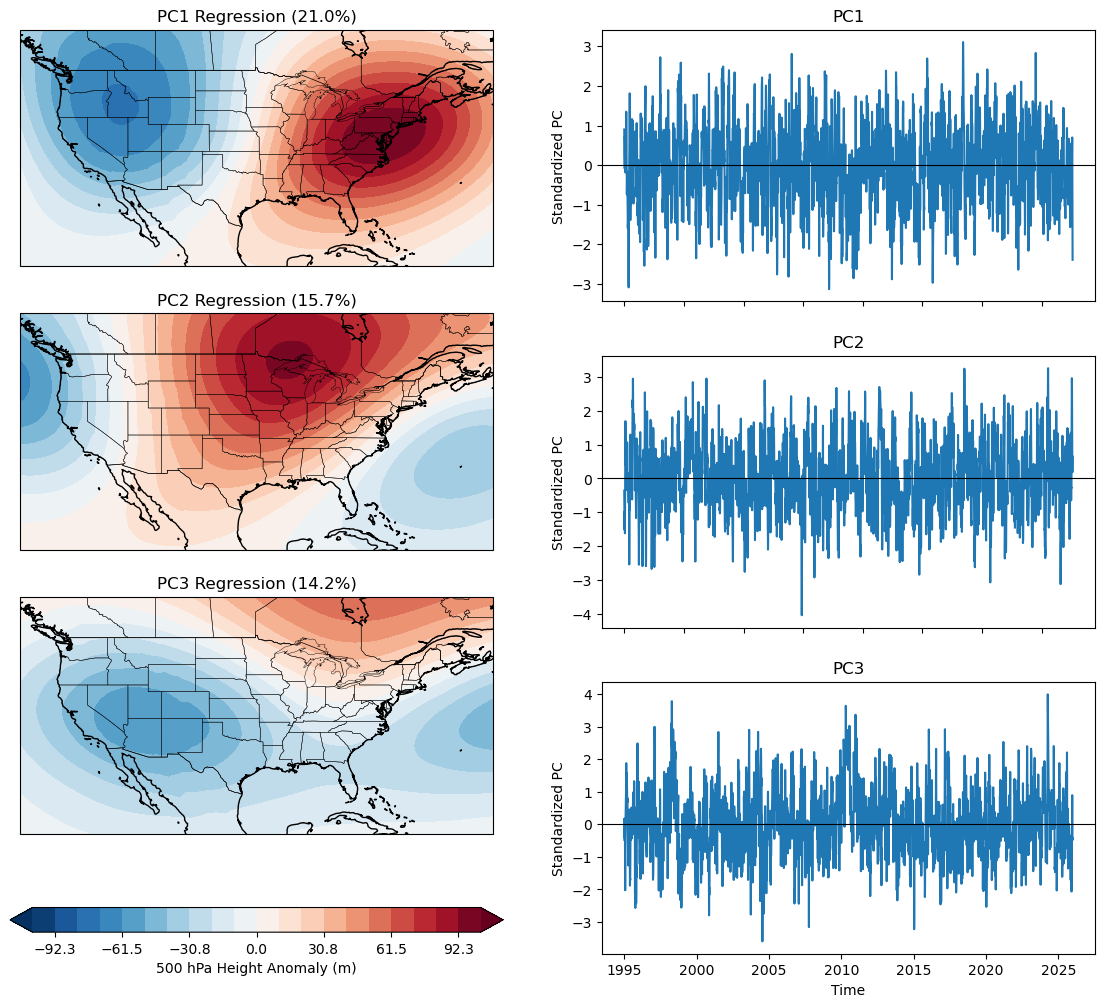

In [51]:
fig = plt.figure(figsize=(14,12))

## For x axis labeling purposes (time)
time = X_new.time.values
years = pd.to_datetime(time).year

tick_years = np.arange(1995, 2030, 5)

tick_positions = []

for yr in tick_years:
    idx = np.where(years == yr)[0]
    
    if len(idx) > 0:
        tick_positions.append(idx[0])

        

# Use common contour levels for all panels
vmax = np.max(np.abs([d1_new,d2_new]))

levels = np.linspace(-vmax, vmax, 21)

# REGRESSION MAP 1

ax1 = plt.subplot(3,2,1,
                  projection=ccrs.PlateCarree())

cf1 = ax1.contourf(
    lon_new,
    lat_new,
    d1_new,
    levels=levels,
    cmap='RdBu_r',
    extend='both',
    transform=ccrs.PlateCarree()
)

ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax1.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='black')

ax1.set_title(f'PC1 Regression ({pve2_new[0]:.1f}%)')

# plt.colorbar(
#     cf1,
#     ax=ax1,
#     orientation='horizontal',
#     pad=0.05,
#     shrink=0.8,
#     label='meters'
# )

# PC1
ax2 = plt.subplot(3,2,2)

ax2.plot(z1_new)

ax2.axhline(0,
            color='k',
            linewidth=0.8)

ax2.set_title('PC1')
ax2.set_ylabel('Standardized PC')
ax2.tick_params(labelbottom=False)


# REGRESSION MAP 2

ax3 = plt.subplot(3,2,3,
                  projection=ccrs.PlateCarree())

cf2 = ax3.contourf(
    lon_new,
    lat_new,
    d2_new,
    levels=levels,
    cmap='RdBu_r',
    extend='both',
    transform=ccrs.PlateCarree()
)

ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax3.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='black')

ax3.set_title(f'PC2 Regression ({pve2_new[1]:.1f}%)')

# plt.colorbar(
#     cf2,
#     ax=ax3,
#     orientation='horizontal',
#     pad=0.05,
#     shrink=0.8,
#     label='meters'
# )

# PC2
ax4 = plt.subplot(3,2,4)

ax4.plot(z2_new)

ax4.axhline(0,
            color='k',
            linewidth=0.8)

ax4.set_title('PC2')
ax4.set_ylabel('Standardized PC')
ax4.tick_params(labelbottom=False)


# REGRESSION MAP 3

ax5 = plt.subplot(3,2,5,
                  projection=ccrs.PlateCarree())

cf3 = ax5.contourf(
    lon_new,
    lat_new,
    d3_new,
    levels=levels,
    cmap='RdBu_r',
    extend='both',
    transform=ccrs.PlateCarree()
)

ax5.coastlines()
ax5.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax5.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='black')


ax5.set_title(f'PC3 Regression ({pve2_new[2]:.1f}%)')

# plt.colorbar(
#     cf3,
#     ax=ax5,
#     orientation='horizontal',
#     pad=0.05,
#     shrink=0.8,
#     label='meters'
# )

# PC3
ax6 = plt.subplot(3,2,6)

ax6.plot(z3_new)

ax6.axhline(0,
            color='k',
            linewidth=0.8)

ax6.set_title('PC3')
ax6.set_ylabel('Standardized PC')
ax6.set_xticks(tick_positions)
ax6.set_xticklabels(tick_years)
ax6.set_xlabel('Time')

cbar = fig.colorbar(
    cf3,
    ax=[ax1,ax3, ax5],
    orientation='horizontal',
    pad=0.08,
    fraction=0.05
)
cbar.set_label('500 hPa Height Anomaly (m)')

#plt.tight_layout()
fig.savefig('EOFs_climo_DJFM_days', dpi=200)
plt.show()
plt.close()

### EOFs for outbreak days but using anomalies with respect to the **full climatology**

In [15]:
## Load in pre-calculated daily climatology
climo = xr.open_dataset('/data1/ERA5/daily_climo/Z_clim_1996-2025.nc')

In [16]:
climo

<xarray.Dataset> Size: 59GB
Dimensions:    (doy: 365, level: 22, latitude: 321, longitude: 1440)
Coordinates:
  * doy        (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * level      (level) float64 176B 1e+03 925.0 850.0 700.0 ... 7.0 5.0 3.0 1.0
  * latitude   (latitude) float64 3kB 90.0 89.75 89.5 89.25 ... 10.5 10.25 10.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    n_years    (doy) int32 1kB ...
Data variables:
    Z_00z      (doy, level, latitude, longitude) float32 15GB ...
    Z_std_00z  (doy, level, latitude, longitude) float32 15GB ...
    Z_12z      (doy, level, latitude, longitude) float32 15GB ...
    Z_std_12z  (doy, level, latitude, longitude) float32 15GB ...

In [17]:
climo_mean_00z = climo['Z_00z'].sel(level=500) / 9.80665
climo_std_00z = climo['Z_std_00z'].sel(level=500) / 9.80665
climo_mean_12z = climo['Z_12z'].sel(level=500) / 9.80665
climo_std_12z = climo['Z_std_12z'].sel(level=500) / 9.80665

In [18]:
climo_mean_00z.coords

Coordinates:
  * doy        (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * latitude   (latitude) float64 3kB 90.0 89.75 89.5 89.25 ... 10.5 10.25 10.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    level      float64 8B 500.0
    n_years    (doy) int32 1kB ...

In [19]:
## Prepare the outbreak data (matching day-of-year)

## Fix the climatology dimensions and leap years
## Create 365 'mm-dd' strings using a dummy non leap year
dates_365 = pd.date_range(start='2023-01-01', end='2023-12-31')
mm_dd_strings = dates_365.strftime('%m-%d')

##Replace the 'doy' integers with 'mm'dd' strings, and rename the dimension
climo_mean_00z = climo_mean_00z.assign_coords(doy=mm_dd_strings).rename({'doy': 'month_day'})
climo_std_00z = climo_std_00z.assign_coords(doy=mm_dd_strings).rename({'doy': 'month_day'})
climo_mean_12z = climo_mean_12z.assign_coords(doy=mm_dd_strings).rename({'doy': 'month_day'})
climo_std_12z = climo_std_12z.assign_coords(doy=mm_dd_strings).rename({'doy': 'month_day'})


In [20]:
X = z_500_all_outbreaks

## Fix outbreak data, remove Feb 29 (since I don't have a daily climatology for that day (why do we have leap years anyway?))
X = X.sel(time=~((X['time'].dt.month==2) & (X['time'].dt.day==29)))

## Create a 'mm-dd' coordinate for the outbreak times
X_mm_dd = X['time'].dt.strftime('%m-%d')
                          
# Assign this new coordinate to the DataArray along the 'time' dimension
X = X.assign_coords(month_day = X_mm_dd)

lat = X['latitude']
lon = X['longitude']

a,b,c = np.shape(X)
print(f"Original shape: {a}, {b}, {c}")

Original shape: 298, 101, 251


In [21]:
## subtract mean based on daily climatology:
X_anom = X.groupby('month_day') - climo_mean_00z

## Detrend:
#calculates the fit between time and SST (deg=1 for linear, deg=2 for quadratic)
fit_results = X_anom.polyfit(dim = 'time', deg=1);

#calculate the trend with time
fit_with_time = xr.polyval(X_anom.time, fit_results);

#subtracts trend from data
X_anom = X_anom - fit_with_time['polyfit_coefficients'];

## Exract unweighted anomalies for regression later
Y = X_anom.values.reshape(a, b * c)

## Standardize
X_stand = X_anom.groupby('month_day') / climo_std_00z

## Cosine weight
X_stand = X_stand*np.sqrt(np.cos(lat*np.pi/180))

## Flatten lat/lon into a single time x location shape for svd
X_matrix = X_stand.values.reshape(a,b*c)

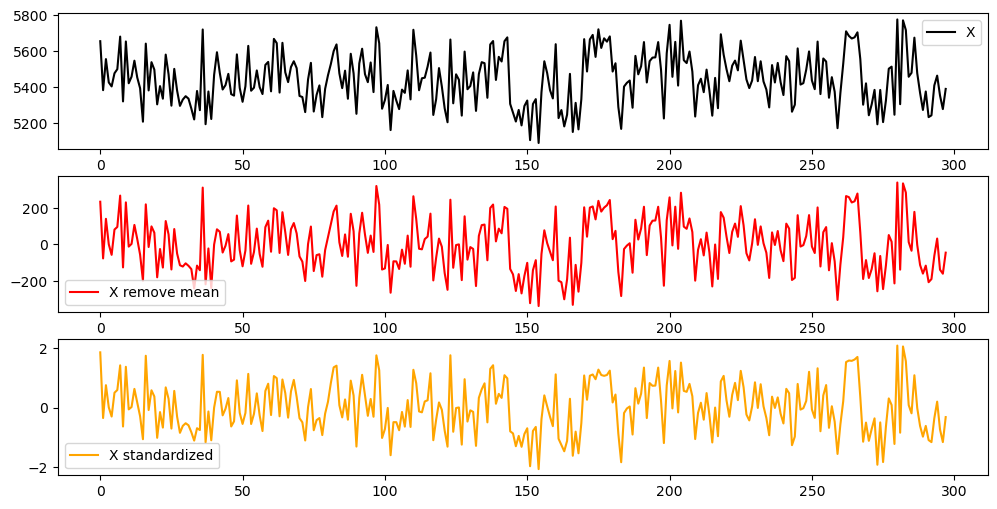

In [22]:
## plot one point to make sure the data have the mean removed and have been standardized

f=plt.figure(figsize=(12,6))
gs=GridSpec(3,1)
plt.subplot(gs[0,0])
plt.plot(X[:,1,1],label='X',color='black')
plt.legend()
plt.subplot(gs[1,0])
plt.plot(X_anom[:,1,1],label='X remove mean',color='red')
plt.legend()
plt.subplot(gs[2,0])
plt.plot(X_stand[:,1,1],label='X standardized',color='orange')
plt.legend()

In [23]:
u,s,v = LA.svd(X_matrix, full_matrices=False)

Percent variance explained by EOF1: 25.0 %
Percent variance explained by EOF2: 19.0 %
Percent variance explained by EOF3: 15.0 %
Percent variance explained by EOF4: 10.0 %
Percent variance explained by EOF5: 8.0 %
Percent variance explained by EOF6: 5.0 %
Percent variance explained by EOF7: 4.0 %
Percent variance explained by EOF8: 2.0 %
Percent variance explained by EOF9: 2.0 %
Percent variance explained by EOF10: 2.0 %
Percent variance explained by EOF11: 1.0 %
Percent variance explained by EOF12: 1.0 %


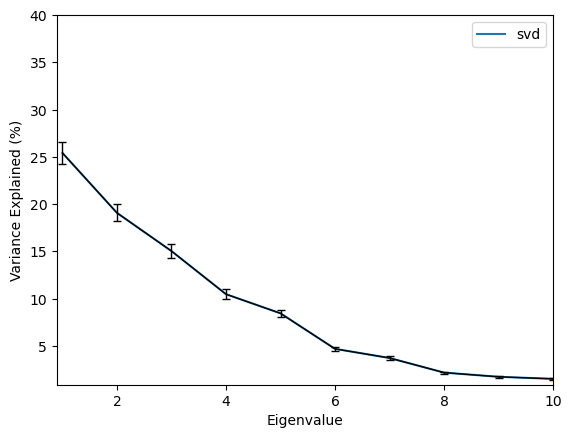

In [24]:
## Plot the eigenvalues

# convert eigenvalues to percent variance explained
pve2 = 100.*np.abs(s**2)/np.sum(np.abs(s**2))
print('Percent variance explained by EOF1:',np.round(pve2[0],0),'%')
print('Percent variance explained by EOF2:',np.round(pve2[1],0),'%')
print('Percent variance explained by EOF3:',np.round(pve2[2],0),'%')
print('Percent variance explained by EOF4:',np.round(pve2[3],0),'%')
print('Percent variance explained by EOF5:',np.round(pve2[4],0),'%')
print('Percent variance explained by EOF6:',np.round(pve2[5],0),'%')
print('Percent variance explained by EOF7:',np.round(pve2[6],0),'%')
print('Percent variance explained by EOF8:',np.round(pve2[7],0),'%')
print('Percent variance explained by EOF9:',np.round(pve2[8],0),'%')
print('Percent variance explained by EOF10:',np.round(pve2[9],0),'%')
print('Percent variance explained by EOF11:',np.round(pve2[10],0),'%')
print('Percent variance explained by EOF12:',np.round(pve2[11],0),'%')

## Hannachi et al. 2007 report observations show EOF1=21% variance, EOF2=13% variance

## Effective sample size calculation:
tseries = np.nanmean(X_stand.values, axis=(1,2))
sigma = np.std(tseries)
mean = np.mean(tseries)
N = len(tseries)
lag = 1

t1_m = tseries[:-lag] - mean
t2_m = tseries[lag:] - mean

alpha = np.correlate(t1_m, t2_m) / ((N-lag) * sigma**2)
alpha = alpha[0]
Nstar = ((1-alpha)/(1+alpha)) * N

eb = pve2 * np.sqrt(2/Nstar)
                     

f=plt.figure()
x = np.arange(1,len(pve2)+1)
plt.plot(x,pve2,label='svd')
plt.errorbar(
    x,
    pve2,
    yerr = eb/2,
    xerr=None,
    linewidth=1,
    color='black',
    capsize=3
)

plt.ylim([0.9,40])
plt.xlim([0.9,10])
plt.ylabel('Variance Explained (%)')
plt.xlabel('Eigenvalue')
plt.legend()
#plt.savefig('eigenvalues_outbreaks_climo');

In [25]:
# select an EOF
eof_num=1

# Find the eigenvector (e1) associated with "eof_num" from the SVD method
print(np.shape(v),np.shape(s),np.shape(u))
e1 = (v[eof_num-1,:]).reshape(b,c)
print(np.shape(e1))

# Calculate the principal component (z1) associated with "eof_num" from the SVD method
z1 = u[:,eof_num-1]*(s[eof_num-1])
## standardize it
z1 = (z1-np.mean(z1))/np.std(z1)  
print(np.shape(z1))

# select an EOF
eof_num=2

# Find the eigenvector (e1) associated with "eof_num" from the SVD method
e2 = (v[eof_num-1,:]).reshape(b,c)
print(np.shape(e1))

# Calculate the principal component (z1) associated with "eof_num" from the SVD method
z2 = u[:,eof_num-1]*(s[eof_num-1])
## standardize it
z2 = (z2-np.mean(z2))/np.std(z2)  
print(np.shape(z2))

# select an EOF
eof_num=3

# Find the eigenvector (e1) associated with "eof_num" from the SVD method
e3 = (v[eof_num-1,:]).reshape(b,c)
print(np.shape(e3))

# Calculate the principal component (z1) associated with "eof_num" from the SVD method
z3 = u[:,eof_num-1]*(s[eof_num-1])
## standardize it
z3 = (z3-np.mean(z3))/np.std(z3)  
print(np.shape(z3))


(298, 25351) (298,) (298, 298)
(101, 251)
(298,)
(101, 251)
(298,)
(101, 251)
(298,)


In [26]:
# calculate d for plotting in physical units, not standardized/weighted units.
## d1 is in physical units (in this case degrees) and denotes the anomaly associated with 1 standard deviation
## of z1 (principal component, time variation in this case)

d1 = (1./np.size(Y, axis=0))*np.dot(np.transpose(z1),Y)
d1 = d1.reshape(b,c)

d2 = (1./np.size(Y,axis=0)) * \
     np.dot(np.transpose(z2), Y)

d2 = d2.reshape(b,c)


d3 = (1./np.size(Y,axis=0)) * \
     np.dot(np.transpose(z3), Y)

d3 = d3.reshape(b,c)

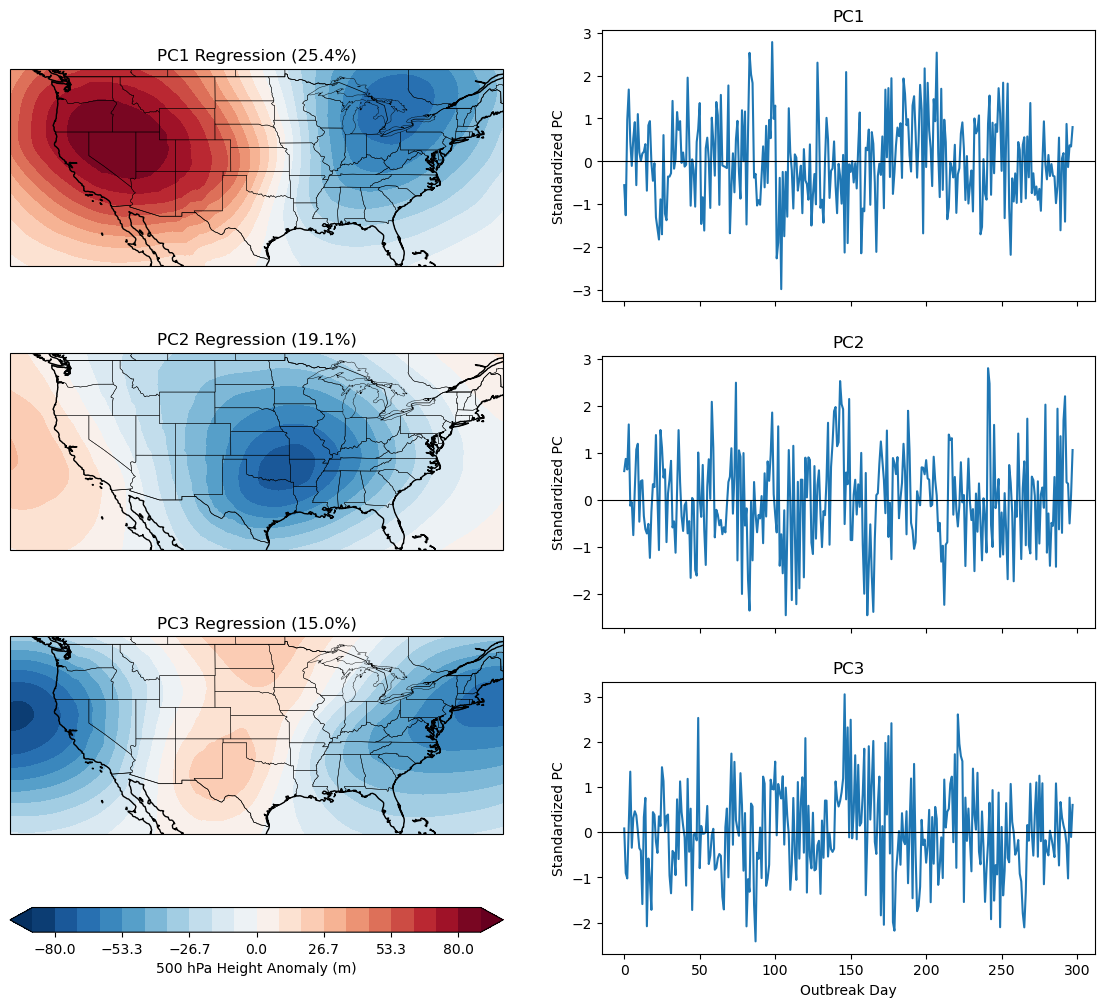

In [29]:
fig = plt.figure(figsize=(14,12))

# Use common contour levels for all panels

vmax = np.max(np.abs([d1,d2]))

levels = np.linspace(-vmax, vmax, 21)

# REGRESSION MAP 1

ax1 = plt.subplot(3,2,1,
                  projection=ccrs.PlateCarree())

cf1 = ax1.contourf(
    lon,
    lat,
    d1,
    levels=levels,
    cmap='RdBu_r',
    extend='both',
    transform=ccrs.PlateCarree()
)

ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax1.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='black')

ax1.set_title(f'PC1 Regression ({pve2[0]:.1f}%)')

# plt.colorbar(
#     cf1,
#     ax=ax1,
#     orientation='horizontal',
#     pad=0.05,
#     shrink=0.8,
#     label='meters'
# )

# PC1
ax2 = plt.subplot(3,2,2)

ax2.plot(z1)

ax2.axhline(0,
            color='k',
            linewidth=0.8)

ax2.set_title('PC1')
ax2.set_ylabel('Standardized PC')
ax2.set_xticklabels([])


# REGRESSION MAP 2

ax3 = plt.subplot(3,2,3,
                  projection=ccrs.PlateCarree())

cf2 = ax3.contourf(
    lon,
    lat,
    d2,
    levels=levels,
    cmap='RdBu_r',
    extend='both',
    transform=ccrs.PlateCarree()
)

ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax3.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='black')

ax3.set_title(f'PC2 Regression ({pve2[1]:.1f}%)')

# plt.colorbar(
#     cf2,
#     ax=ax3,
#     orientation='horizontal',
#     pad=0.05,
#     shrink=0.8,
#     label='meters'
# )

# PC2
ax4 = plt.subplot(3,2,4)

ax4.plot(z2)

ax4.axhline(0,
            color='k',
            linewidth=0.8)

ax4.set_title('PC2')
ax4.set_ylabel('Standardized PC')
ax4.set_xticklabels([])


# REGRESSION MAP 3

ax5 = plt.subplot(3,2,5,
                  projection=ccrs.PlateCarree())

cf3 = ax5.contourf(
    lon,
    lat,
    d3,
    levels=levels,
    cmap='RdBu_r',
    extend='both',
    transform=ccrs.PlateCarree()
)

ax5.coastlines()
ax5.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax5.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='black')


ax5.set_title(f'PC3 Regression ({pve2[2]:.1f}%)')

# plt.colorbar(
#     cf3,
#     ax=ax5,
#     orientation='horizontal',
#     pad=0.05,
#     shrink=0.8,
#     label='meters'
# )

#PC3
ax6 = plt.subplot(3,2,6)

ax6.plot(z3)

ax6.axhline(0,
            color='k',
            linewidth=0.8)

ax6.set_title('PC3')
ax6.set_ylabel('Standardized PC')
ax6.set_xlabel('Outbreak Day')

cbar = fig.colorbar(
    cf3,
    ax=[ax1,ax3, ax5],
    orientation='horizontal',
    pad=0.08,
    fraction=0.05
)
cbar.set_label('500 hPa Height Anomaly (m)')

#plt.tight_layout()
#fig.savefig('EOFs_DJFM_outbreak_days_climo', dpi=200)
plt.show()
plt.close()

## Plotting Storm Reports Associated with Specific PCs

In [30]:
## Map each z1 index → OUTBREAK_DAY via ERA5_time
era5_times = pd.to_datetime(X.time.values)  # tz-naive (from ERA5 grib)

# Normalize ERA5_time keys to tz-naive to match X.time
outbreak_era5 = pd.to_datetime(outbreak_days['ERA5_time'])
if outbreak_era5.dt.tz is not None:
    outbreak_era5 = outbreak_era5.dt.tz_convert('UTC').dt.tz_localize(None)

era5_to_outbreak = dict(zip(
    outbreak_era5,
    pd.to_datetime(outbreak_days['OUTBREAK_DAY'])
))

In [31]:
outbreak_day_per_pc = [era5_to_outbreak[t] for t in era5_times]


#outbreak_day_per_pc = [
#    era5_to_outbreak.get(t, pd.NaT)
#    for t in era5_times
#]

In [32]:
type(era5_times)

pandas.core.indexes.datetimes.DatetimeIndex

In [33]:
outbreak_day_per_pc

[Timestamp('1996-03-24 00:00:00'),
 Timestamp('1996-01-18 00:00:00'),
 Timestamp('1996-03-06 00:00:00'),
 Timestamp('1996-03-18 00:00:00'),
 Timestamp('1996-03-30 00:00:00'),
 Timestamp('1996-03-05 00:00:00'),
 Timestamp('1996-03-14 00:00:00'),
 Timestamp('1996-03-15 00:00:00'),
 Timestamp('1996-01-19 00:00:00'),
 Timestamp('1996-03-16 00:00:00'),
 Timestamp('1996-12-23 00:00:00'),
 Timestamp('1997-01-24 00:00:00'),
 Timestamp('1997-02-21 00:00:00'),
 Timestamp('1997-03-28 00:00:00'),
 Timestamp('1997-03-29 00:00:00'),
 Timestamp('1997-03-01 00:00:00'),
 Timestamp('1997-03-24 00:00:00'),
 Timestamp('1997-03-05 00:00:00'),
 Timestamp('1997-02-20 00:00:00'),
 Timestamp('1997-01-05 00:00:00'),
 Timestamp('1998-02-10 00:00:00'),
 Timestamp('1998-02-26 00:00:00'),
 Timestamp('1998-03-30 00:00:00'),
 Timestamp('1998-03-29 00:00:00'),
 Timestamp('1998-03-07 00:00:00'),
 Timestamp('1998-02-17 00:00:00'),
 Timestamp('1998-03-20 00:00:00'),
 Timestamp('1998-02-25 00:00:00'),
 Timestamp('1998-03-

In [42]:
pos_dates = {
    d for i, d in enumerate(outbreak_day_per_pc)
    if z1[i] >= 1 and pd.notna(d)
}
neg_dates = {
    d for i, d in enumerate(outbreak_day_per_pc)
    if z1[i] <= -1 and pd.notna(d)
}

## Filter storm reports (6Z-6Z convention matches outbreak definition)
sub = df_winter_scs_subset.copy()
sub['OUTBREAK_DAY'] = pd.to_datetime(
    (sub['BEGIN_DT_UTC'] - pd.Timedelta(hours=6)).dt.date
)
pos_reports = sub[sub['OUTBREAK_DAY'].isin(pos_dates)]
neg_reports = sub[sub['OUTBREAK_DAY'].isin(neg_dates)]

percentage_pos_tor = 100 * (pos_reports['EVENT_TYPE'] == 'Tornado').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_tor = 100 * (neg_reports['EVENT_TYPE'] == 'Tornado').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

percentage_pos_hail = 100 * (pos_reports['EVENT_TYPE'] == 'Hail').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_hail = 100 * (neg_reports['EVENT_TYPE'] == 'Hail').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

percentage_pos_wind = 100 * (pos_reports['EVENT_TYPE'] == 'Thunderstorm Wind').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_wind = 100 * (neg_reports['EVENT_TYPE'] == 'Thunderstorm Wind').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

pos_pct = {
    'Tornado': percentage_pos_tor,
    'Hail': percentage_pos_hail,
    'Thunderstorm Wind': percentage_pos_wind,
}
neg_pct = {
    'Tornado': percentage_neg_tor,
    'Hail': percentage_neg_hail,
    'Thunderstorm Wind': percentage_neg_wind,
}

print(f'Positive phase days (PC1 >= 1): {len(pos_dates)}')
print(f'Negative phase days (PC1 <= -1): {len(neg_dates)}')
print(f'Positive phase reports: {len(pos_reports)}')
print(f'Negative phase reports: {len(neg_reports)}')


Positive phase days (PC1 >= 1): 45
Negative phase days (PC1 <= -1): 49
Positive phase reports: 6888
Negative phase reports: 9658


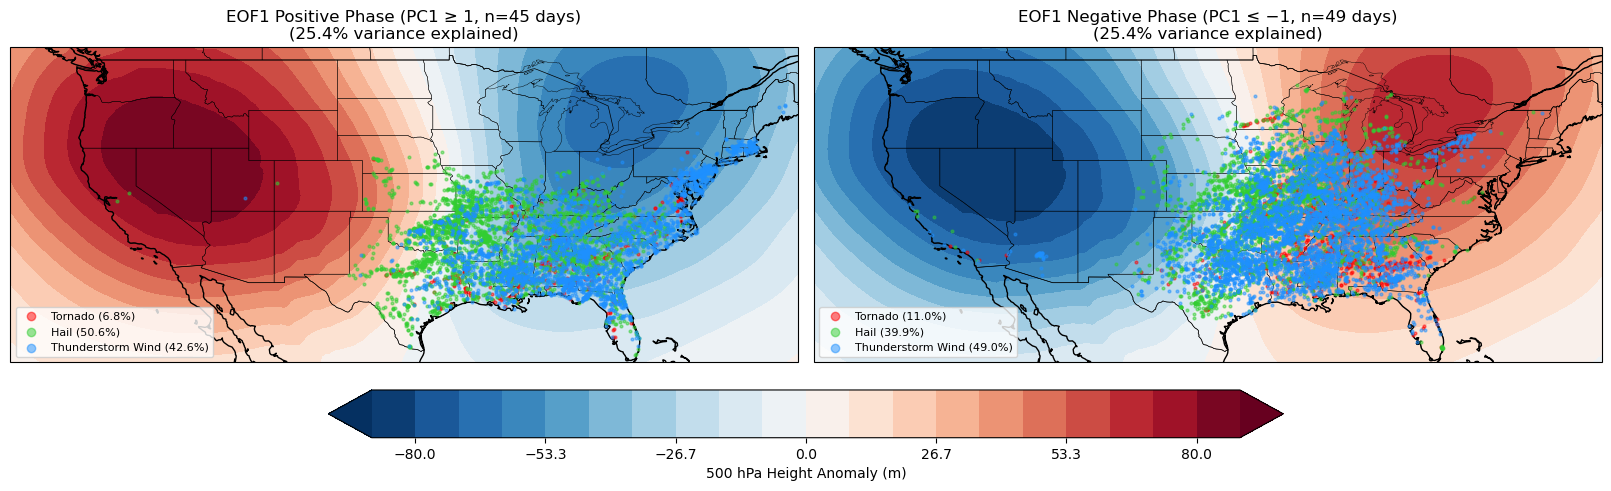

In [43]:
event_colors = {
    'Tornado':           'red',
    'Hail':              'limegreen',
    'Thunderstorm Wind': 'dodgerblue',
}

vmax_d1 = np.max(np.abs(d1))
levels_d1 = np.linspace(-vmax_d1, vmax_d1, 21)

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

panels = [
    (axes[0], pos_reports, d1,
     f'EOF1 Positive Phase (PC1 ≥ 1, n={len(pos_dates)} days)', pos_pct),
    (axes[1], neg_reports, -d1,
     f'EOF1 Negative Phase (PC1 ≤ −1, n={len(neg_dates)} days)', neg_pct),
]

for ax, reports, pattern, title, pct_map in panels:
    cf = ax.contourf(
        lon, lat, pattern,
        levels=levels_d1, cmap='RdBu_r', extend='both',
        transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
    ax.add_feature(cfeature.STATES,  linewidth=0.3, edgecolor='black')
    ax.set_extent([-130, -67.5, 25, 50], crs=ccrs.PlateCarree())
    for etype, color in event_colors.items():
        mask = reports['EVENT_TYPE'] == etype
        pct = pct_map.get(etype, 0)
        ax.scatter(
            reports.loc[mask, 'BEGIN_LON'],
            reports.loc[mask, 'BEGIN_LAT'],
            s=4, color=color, alpha=0.5,
            transform=ccrs.PlateCarree(),
            label=f'{etype} ({pct:.1f}%)', zorder=5
        )
    ax.set_title(f'{title}\n({pve2[0]:.1f}% variance explained)')
    ax.legend(loc='lower left', markerscale=3, fontsize=8)

cbar = fig.colorbar(
    cf, ax=axes,
    orientation='horizontal', pad=0.05, shrink=0.6
)
cbar.set_label('500 hPa Height Anomaly (m)')
fig.savefig('EOF1_storm_reports_by_phase', dpi=200, bbox_inches='tight')
plt.show()
plt.close()


#### Same for EOF 2:

In [44]:
pos_dates = {
    d for i, d in enumerate(outbreak_day_per_pc)
    if z2[i] >= 1 and pd.notna(d)
}
neg_dates = {
    d for i, d in enumerate(outbreak_day_per_pc)
    if z2[i] <= -1 and pd.notna(d)
}

## Filter storm reports (6Z-6Z convention matches outbreak definition)
sub = df_winter_scs_subset.copy()
sub['OUTBREAK_DAY'] = pd.to_datetime(
    (sub['BEGIN_DT_UTC'] - pd.Timedelta(hours=6)).dt.date
)
pos_reports = sub[sub['OUTBREAK_DAY'].isin(pos_dates)]
neg_reports = sub[sub['OUTBREAK_DAY'].isin(neg_dates)]

percentage_pos_tor = 100 * (pos_reports['EVENT_TYPE'] == 'Tornado').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_tor = 100 * (neg_reports['EVENT_TYPE'] == 'Tornado').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

percentage_pos_hail = 100 * (pos_reports['EVENT_TYPE'] == 'Hail').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_hail = 100 * (neg_reports['EVENT_TYPE'] == 'Hail').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

percentage_pos_wind = 100 * (pos_reports['EVENT_TYPE'] == 'Thunderstorm Wind').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_wind = 100 * (neg_reports['EVENT_TYPE'] == 'Thunderstorm Wind').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

pos_pct = {
    'Tornado': percentage_pos_tor,
    'Hail': percentage_pos_hail,
    'Thunderstorm Wind': percentage_pos_wind,
}
neg_pct = {
    'Tornado': percentage_neg_tor,
    'Hail': percentage_neg_hail,
    'Thunderstorm Wind': percentage_neg_wind,
}

print(f'Positive phase days (PC2 >= 1): {len(pos_dates)}')
print(f'Negative phase days (PC2 <= -1): {len(neg_dates)}')
print(f'Positive phase reports: {len(pos_reports)}')
print(f'Negative phase reports: {len(neg_reports)}')
print('-'* 50)
print(percentage_pos_tor)
print(percentage_neg_tor)
print(percentage_pos_hail)
print(percentage_neg_hail)
print(percentage_pos_wind)
print(percentage_neg_wind)

Positive phase days (PC2 >= 1): 46
Negative phase days (PC2 <= -1): 44
Positive phase reports: 8708
Negative phase reports: 9390
--------------------------------------------------
9.715204409738172
7.380191693290735
28.81258612769867
52.50266240681576
61.47220946256316
40.1171458998935


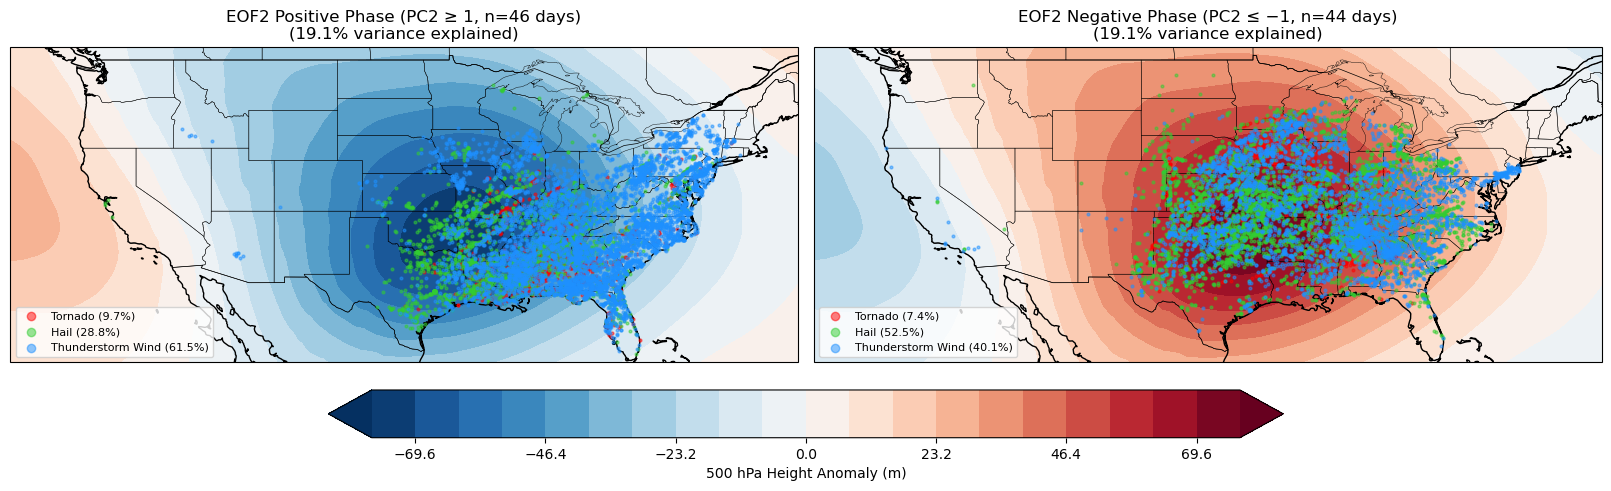

In [45]:
event_colors = {
    'Tornado':           'red',
    'Hail':              'limegreen',
    'Thunderstorm Wind': 'dodgerblue',
}

vmax_d2 = np.max(np.abs(d2))
levels_d2 = np.linspace(-vmax_d2, vmax_d2, 21)

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

panels = [
    (axes[0], pos_reports, d2,
     f'EOF2 Positive Phase (PC2 \u2265 1, n={len(pos_dates)} days)', pos_pct),
    (axes[1], neg_reports, -d2,
     f'EOF2 Negative Phase (PC2 \u2264 \u22121, n={len(neg_dates)} days)', neg_pct),
]

for ax, reports, pattern, title, pct_map in panels:
    cf = ax.contourf(
        lon, lat, pattern,
        levels=levels_d2, cmap='RdBu_r', extend='both',
        transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
    ax.add_feature(cfeature.STATES,  linewidth=0.3, edgecolor='black')
    ax.set_extent([-130, -67.5, 25, 50], crs=ccrs.PlateCarree())
    for etype, color in event_colors.items():
        mask = reports['EVENT_TYPE'] == etype
        pct = pct_map.get(etype, 0)
        ax.scatter(
            reports.loc[mask, 'BEGIN_LON'],
            reports.loc[mask, 'BEGIN_LAT'],
            s=4, color=color, alpha=0.5,
            transform=ccrs.PlateCarree(),
            label=f'{etype} ({pct:.1f}%)', zorder=5
        )
    ax.set_title(f'{title}\n({pve2[1]:.1f}% variance explained)')
    ax.legend(loc='lower left', markerscale=3, fontsize=8)

cbar = fig.colorbar(
    cf, ax=axes,
    orientation='horizontal', pad=0.05, shrink=0.6
)
cbar.set_label('500 hPa Height Anomaly (m)')

fig.savefig('EOF2_storm_reports_by_phase', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

#### EOF 3:

In [46]:
pos_dates = {
    d for i, d in enumerate(outbreak_day_per_pc)
    if z3[i] >= 1 and pd.notna(d)
}
neg_dates = {
    d for i, d in enumerate(outbreak_day_per_pc)
    if z3[i] <= -1 and pd.notna(d)
}

## Filter storm reports (6Z-6Z convention matches outbreak definition)
sub = df_winter_scs_subset.copy()
sub['OUTBREAK_DAY'] = pd.to_datetime(
    (sub['BEGIN_DT_UTC'] - pd.Timedelta(hours=6)).dt.date
)
pos_reports = sub[sub['OUTBREAK_DAY'].isin(pos_dates)]
neg_reports = sub[sub['OUTBREAK_DAY'].isin(neg_dates)]

percentage_pos_tor = 100 * (pos_reports['EVENT_TYPE'] == 'Tornado').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_tor = 100 * (neg_reports['EVENT_TYPE'] == 'Tornado').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

percentage_pos_hail = 100 * (pos_reports['EVENT_TYPE'] == 'Hail').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_hail = 100 * (neg_reports['EVENT_TYPE'] == 'Hail').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

percentage_pos_wind = 100 * (pos_reports['EVENT_TYPE'] == 'Thunderstorm Wind').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_wind = 100 * (neg_reports['EVENT_TYPE'] == 'Thunderstorm Wind').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

pos_pct = {
    'Tornado': percentage_pos_tor,
    'Hail': percentage_pos_hail,
    'Thunderstorm Wind': percentage_pos_wind,
}
neg_pct = {
    'Tornado': percentage_neg_tor,
    'Hail': percentage_neg_hail,
    'Thunderstorm Wind': percentage_neg_wind,
}

print(f'Positive phase days (PC3 >= 1): {len(pos_dates)}')
print(f'Negative phase days (PC3 <= -1): {len(neg_dates)}')
print(f'Positive phase reports: {len(pos_reports)}')
print(f'Negative phase reports: {len(neg_reports)}')


Positive phase days (PC3 >= 1): 51
Negative phase days (PC3 <= -1): 47
Positive phase reports: 8611
Negative phase reports: 10509


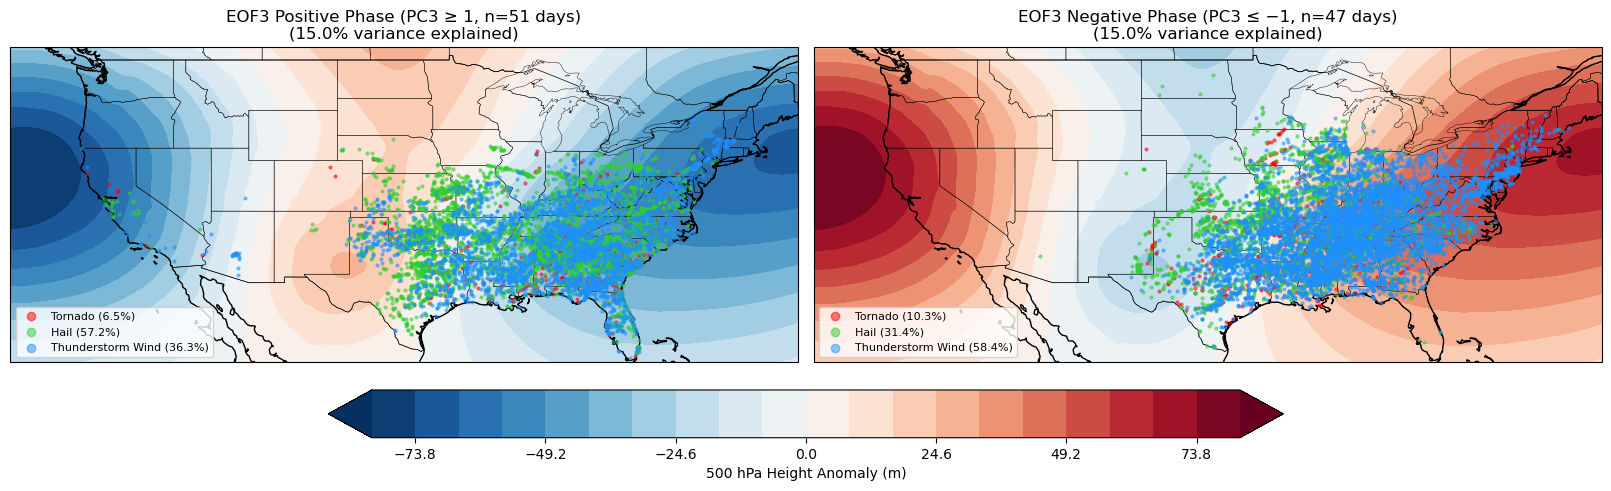

In [47]:
event_colors = {
    'Tornado':           'red',
    'Hail':              'limegreen',
    'Thunderstorm Wind': 'dodgerblue',
}

vmax_d3 = np.max(np.abs(d3))
levels_d3 = np.linspace(-vmax_d3, vmax_d3, 21)

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

panels = [
    (axes[0], pos_reports, d3,
     f'EOF3 Positive Phase (PC3 ≥ 1, n={len(pos_dates)} days)', pos_pct),
    (axes[1], neg_reports, -d3,
     f'EOF3 Negative Phase (PC3 ≤ −1, n={len(neg_dates)} days)', neg_pct),
]

for ax, reports, pattern, title, pct_map in panels:
    cf = ax.contourf(
        lon, lat, pattern,
        levels=levels_d3, cmap='RdBu_r', extend='both',
        transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
    ax.add_feature(cfeature.STATES,  linewidth=0.3, edgecolor='black')
    ax.set_extent([-130, -67.5, 25, 50], crs=ccrs.PlateCarree())
    for etype, color in event_colors.items():
        mask = reports['EVENT_TYPE'] == etype
        pct = pct_map.get(etype, 0)
        ax.scatter(
            reports.loc[mask, 'BEGIN_LON'],
            reports.loc[mask, 'BEGIN_LAT'],
            s=4, color=color, alpha=0.5,
            transform=ccrs.PlateCarree(),
            label=f'{etype} ({pct:.1f}%)', zorder=5
        )
    ax.set_title(f'{title}\n({pve2[2]:.1f}% variance explained)')
    ax.legend(loc='lower left', markerscale=3, fontsize=8)

cbar = fig.colorbar(
    cf, ax=axes,
    orientation='horizontal', pad=0.05, shrink=0.6
)
cbar.set_label('500 hPa Height Anomaly (m)')

fig.savefig('EOF3_storm_reports_by_phase', dpi=200, bbox_inches='tight')
plt.show()
plt.close()


### Recreating the above maps but using contours for storm reports instead of raw storm reports using KDE

In [59]:
## Define a grid matching the map extent
lon_grid = np.linspace(-125,-67,300)
lat_grid = np.linspace(25,55,200)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
grid_pts = np.vstack([lon_mesh.ravel(), lat_mesh.ravel()])


In [119]:
pos_dates = {
    d for i, d in enumerate(outbreak_day_per_pc)
    if z1[i] >= 1 and pd.notna(d)
}
neg_dates = {
    d for i, d in enumerate(outbreak_day_per_pc)
    if z1[i] <= -1 and pd.notna(d)
}

## Filter storm reports (6Z-6Z convention matches outbreak definition)
sub = df_winter_scs_subset.copy()
sub['OUTBREAK_DAY'] = pd.to_datetime(
    (sub['BEGIN_DT_UTC'] - pd.Timedelta(hours=6)).dt.date
)
pos_reports = sub[sub['OUTBREAK_DAY'].isin(pos_dates)]
neg_reports = sub[sub['OUTBREAK_DAY'].isin(neg_dates)]

percentage_pos_tor = 100 * (pos_reports['EVENT_TYPE'] == 'Tornado').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_tor = 100 * (neg_reports['EVENT_TYPE'] == 'Tornado').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

percentage_pos_hail = 100 * (pos_reports['EVENT_TYPE'] == 'Hail').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_hail = 100 * (neg_reports['EVENT_TYPE'] == 'Hail').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

percentage_pos_wind = 100 * (pos_reports['EVENT_TYPE'] == 'Thunderstorm Wind').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_wind = 100 * (neg_reports['EVENT_TYPE'] == 'Thunderstorm Wind').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

pos_pct = {
    'Tornado': percentage_pos_tor,
    'Hail': percentage_pos_hail,
    'Thunderstorm Wind': percentage_pos_wind,
}
neg_pct = {
    'Tornado': percentage_neg_tor,
    'Hail': percentage_neg_hail,
    'Thunderstorm Wind': percentage_neg_wind,
}

print(f'Positive phase days (PC1 >= 1): {len(pos_dates)}')
print(f'Negative phase days (PC1 <= -1): {len(neg_dates)}')
print(f'Positive phase reports: {len(pos_reports)}')
print(f'Negative phase reports: {len(neg_reports)}')


Positive phase days (PC1 >= 1): 45
Negative phase days (PC1 <= -1): 49
Positive phase reports: 6888
Negative phase reports: 9658


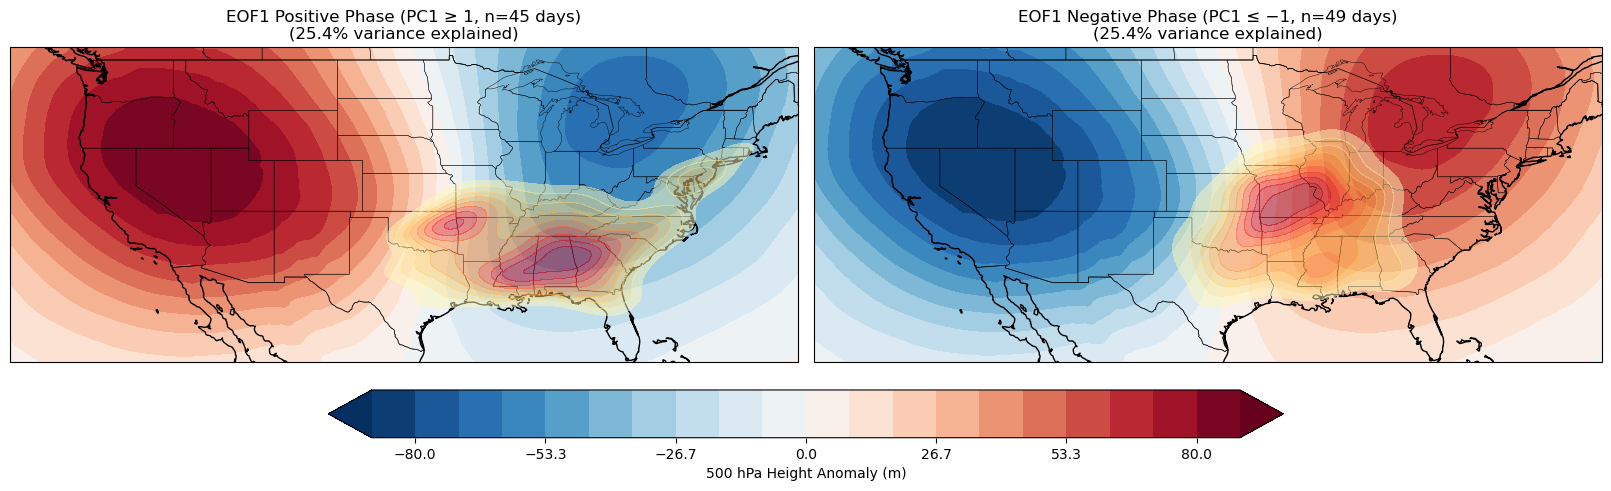

In [120]:
event_colors = {
    'Tornado':           'red',
    'Hail':              'limegreen',
    'Thunderstorm Wind': 'dodgerblue',
}

vmax_d1 = np.max(np.abs(d1))
levels_d1 = np.linspace(-vmax_d1, vmax_d1, 21)

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

panels = [
    (axes[0], pos_reports, d1,
     f'EOF1 Positive Phase (PC1 ≥ 1, n={len(pos_dates)} days)', pos_pct),
    (axes[1], neg_reports, -d1,
     f'EOF1 Negative Phase (PC1 ≤ −1, n={len(neg_dates)} days)', neg_pct),
]

for ax, reports, pattern, title, pct_map in panels:
    cf = ax.contourf(
        lon, lat, pattern,
        levels=levels_d1, cmap='RdBu_r', extend='both',
        transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
    ax.add_feature(cfeature.STATES,  linewidth=0.3, edgecolor='black')
    ax.set_extent([-130, -67.5, 25, 50], crs=ccrs.PlateCarree())
    # for etype, color in event_colors.items():
    #     mask = reports['EVENT_TYPE'] == etype
    #     pct = pct_map.get(etype, 0)
    #     ax.scatter(
    #         reports.loc[mask, 'BEGIN_LON'],
    #         reports.loc[mask, 'BEGIN_LAT'],
    #         s=4, color=color, alpha=0.5,
    #         transform=ccrs.PlateCarree(),
    #         label=f'{etype} ({pct:.1f}%)', zorder=5
    #     )
    lon_grid = np.linspace(-125,-67,300)
    lat_grid = np.linspace(25,55,200)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
    grid_pts = np.vstack([lon_mesh.ravel(), lat_mesh.ravel()])

    pts = reports[['BEGIN_LON', 'BEGIN_LAT']].dropna().values
    kde = gaussian_kde(pts.T, bw_method=0.3) ## increase bw to smooth more, decrease to sharpen
    density = kde(grid_pts).reshape(lat_mesh.shape)

    threshold=0.0015
    levels = np.linspace(threshold, density.max(), 10)

    ax.contourf(
        lon_mesh, lat_mesh, density,
        levels=levels,
        cmap='YlOrRd', alpha=0.5,
        #linewidths=3,
        transform = ccrs.PlateCarree(),
        zorder=5
    )


    ax.set_title(f'{title}\n({pve2[0]:.1f}% variance explained)')
    
    #ax.legend(loc='lower left', markerscale=3, fontsize=8)

cbar = fig.colorbar(
    cf, ax=axes,
    orientation='horizontal', pad=0.05, shrink=0.6
)
cbar.set_label('500 hPa Height Anomaly (m)')
fig.savefig('EOF1_storm_reports_by_phase(2)', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

In [121]:
pos_dates = {
    d for i, d in enumerate(outbreak_day_per_pc)
    if z2[i] >= 1 and pd.notna(d)
}
neg_dates = {
    d for i, d in enumerate(outbreak_day_per_pc)
    if z2[i] <= -1 and pd.notna(d)
}

## Filter storm reports (6Z-6Z convention matches outbreak definition)
sub = df_winter_scs_subset.copy()
sub['OUTBREAK_DAY'] = pd.to_datetime(
    (sub['BEGIN_DT_UTC'] - pd.Timedelta(hours=6)).dt.date
)
pos_reports = sub[sub['OUTBREAK_DAY'].isin(pos_dates)]
neg_reports = sub[sub['OUTBREAK_DAY'].isin(neg_dates)]

percentage_pos_tor = 100 * (pos_reports['EVENT_TYPE'] == 'Tornado').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_tor = 100 * (neg_reports['EVENT_TYPE'] == 'Tornado').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

percentage_pos_hail = 100 * (pos_reports['EVENT_TYPE'] == 'Hail').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_hail = 100 * (neg_reports['EVENT_TYPE'] == 'Hail').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

percentage_pos_wind = 100 * (pos_reports['EVENT_TYPE'] == 'Thunderstorm Wind').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_wind = 100 * (neg_reports['EVENT_TYPE'] == 'Thunderstorm Wind').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

pos_pct = {
    'Tornado': percentage_pos_tor,
    'Hail': percentage_pos_hail,
    'Thunderstorm Wind': percentage_pos_wind,
}
neg_pct = {
    'Tornado': percentage_neg_tor,
    'Hail': percentage_neg_hail,
    'Thunderstorm Wind': percentage_neg_wind,
}

print(f'Positive phase days (PC2 >= 1): {len(pos_dates)}')
print(f'Negative phase days (PC2 <= -1): {len(neg_dates)}')
print(f'Positive phase reports: {len(pos_reports)}')
print(f'Negative phase reports: {len(neg_reports)}')
print('-'* 50)
print(percentage_pos_tor)
print(percentage_neg_tor)
print(percentage_pos_hail)
print(percentage_neg_hail)
print(percentage_pos_wind)
print(percentage_neg_wind)

Positive phase days (PC2 >= 1): 46
Negative phase days (PC2 <= -1): 44
Positive phase reports: 8708
Negative phase reports: 9390
--------------------------------------------------
9.715204409738172
7.380191693290735
28.81258612769867
52.50266240681576
61.47220946256316
40.1171458998935


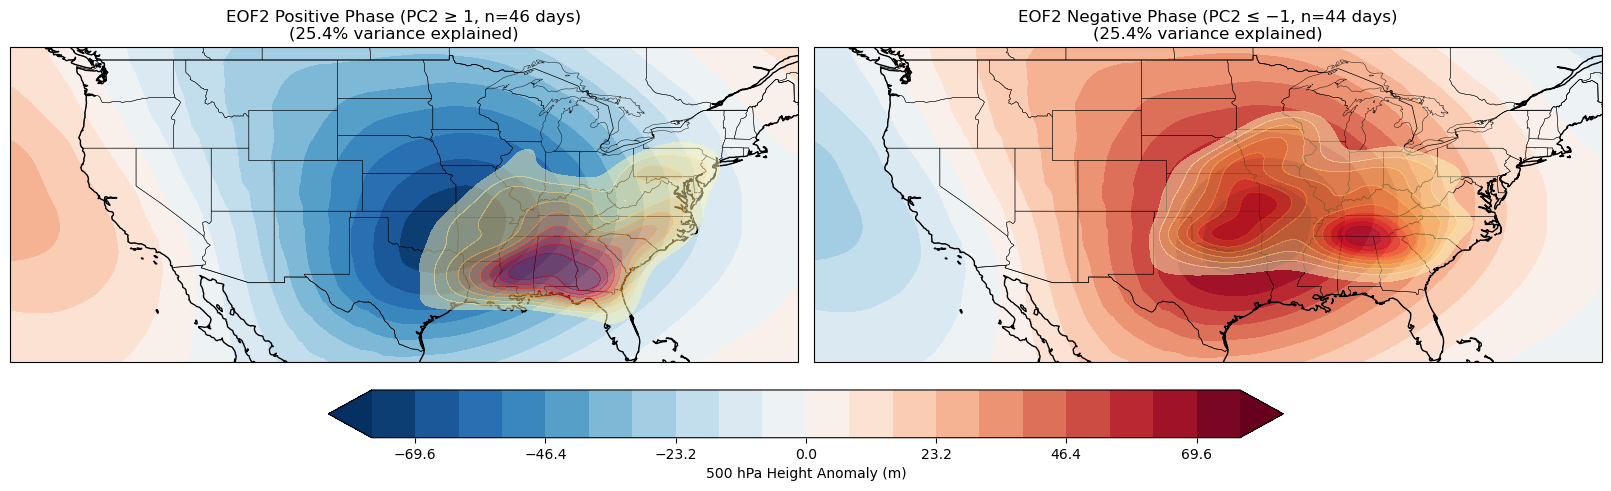

In [ ]:
event_colors = {
    'Tornado':           'red',
    'Hail':              'limegreen',
    'Thunderstorm Wind': 'dodgerblue',
}

vmax_d2 = np.max(np.abs(d2))
levels_d2 = np.linspace(-vmax_d2, vmax_d2, 21)

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

panels = [
    (axes[0], pos_reports, d2,
     f'EOF2 Positive Phase (PC2 ≥ 1, n={len(pos_dates)} days)', pos_pct),
    (axes[1], neg_reports, -d2,
     f'EOF2 Negative Phase (PC2 ≤ −1, n={len(neg_dates)} days)', neg_pct),
]

for ax, reports, pattern, title, pct_map in panels:
    cf = ax.contourf(
        lon, lat, pattern,
        levels=levels_d2, cmap='RdBu_r', extend='both',
        transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
    ax.add_feature(cfeature.STATES,  linewidth=0.3, edgecolor='black')
    ax.set_extent([-130, -67.5, 25, 50], crs=ccrs.PlateCarree())
    # for etype, color in event_colors.items():
    #     mask = reports['EVENT_TYPE'] == etype
    #     pct = pct_map.get(etype, 0)
    #     ax.scatter(
    #         reports.loc[mask, 'BEGIN_LON'],
    #         reports.loc[mask, 'BEGIN_LAT'],
    #         s=4, color=color, alpha=0.5,
    #         transform=ccrs.PlateCarree(),
    #         label=f'{etype} ({pct:.1f}%)', zorder=5
    #     )
    lon_grid = np.linspace(-125,-67,300)
    lat_grid = np.linspace(25,55,200)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
    grid_pts = np.vstack([lon_mesh.ravel(), lat_mesh.ravel()])

    pts = reports[['BEGIN_LON', 'BEGIN_LAT']].dropna().values
    kde = gaussian_kde(pts.T, bw_method=0.30) ## increase bw to smooth more, decrease to sharpen
    density = kde(grid_pts).reshape(lat_mesh.shape)

    threshold=0.0015
    levels = np.linspace(threshold, density.max(), 10)
    
    ax.contourf(
        lon_mesh, lat_mesh, density,
        levels=levels,
        cmap='YlOrRd', alpha=0.5,
        #linewidths=3,
        transform = ccrs.PlateCarree(),
        zorder=5
    )


    ax.set_title(f'{title}\n({pve2[1]:.1f}% variance explained)')
    #ax.legend(loc='lower left', markerscale=3, fontsize=8)

cbar = fig.colorbar(
    cf, ax=axes,
    orientation='horizontal', pad=0.05, shrink=0.6
)
cbar.set_label('500 hPa Height Anomaly (m)')
fig.savefig('EOF2_storm_reports_by_phase(2)', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

In [123]:
pos_dates = {
    d for i, d in enumerate(outbreak_day_per_pc)
    if z3[i] >= 1 and pd.notna(d)
}
neg_dates = {
    d for i, d in enumerate(outbreak_day_per_pc)
    if z3[i] <= -1 and pd.notna(d)
}

## Filter storm reports (6Z-6Z convention matches outbreak definition)
sub = df_winter_scs_subset.copy()
sub['OUTBREAK_DAY'] = pd.to_datetime(
    (sub['BEGIN_DT_UTC'] - pd.Timedelta(hours=6)).dt.date
)
pos_reports = sub[sub['OUTBREAK_DAY'].isin(pos_dates)]
neg_reports = sub[sub['OUTBREAK_DAY'].isin(neg_dates)]

percentage_pos_tor = 100 * (pos_reports['EVENT_TYPE'] == 'Tornado').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_tor = 100 * (neg_reports['EVENT_TYPE'] == 'Tornado').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

percentage_pos_hail = 100 * (pos_reports['EVENT_TYPE'] == 'Hail').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_hail = 100 * (neg_reports['EVENT_TYPE'] == 'Hail').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

percentage_pos_wind = 100 * (pos_reports['EVENT_TYPE'] == 'Thunderstorm Wind').sum() / len(pos_reports) if len(pos_reports) > 0 else 0
percentage_neg_wind = 100 * (neg_reports['EVENT_TYPE'] == 'Thunderstorm Wind').sum() / len(neg_reports) if len(neg_reports) > 0 else 0

pos_pct = {
    'Tornado': percentage_pos_tor,
    'Hail': percentage_pos_hail,
    'Thunderstorm Wind': percentage_pos_wind,
}
neg_pct = {
    'Tornado': percentage_neg_tor,
    'Hail': percentage_neg_hail,
    'Thunderstorm Wind': percentage_neg_wind,
}

print(f'Positive phase days (PC3 >= 1): {len(pos_dates)}')
print(f'Negative phase days (PC3 <= -1): {len(neg_dates)}')
print(f'Positive phase reports: {len(pos_reports)}')
print(f'Negative phase reports: {len(neg_reports)}')

Positive phase days (PC3 >= 1): 51
Negative phase days (PC3 <= -1): 47
Positive phase reports: 8611
Negative phase reports: 10509


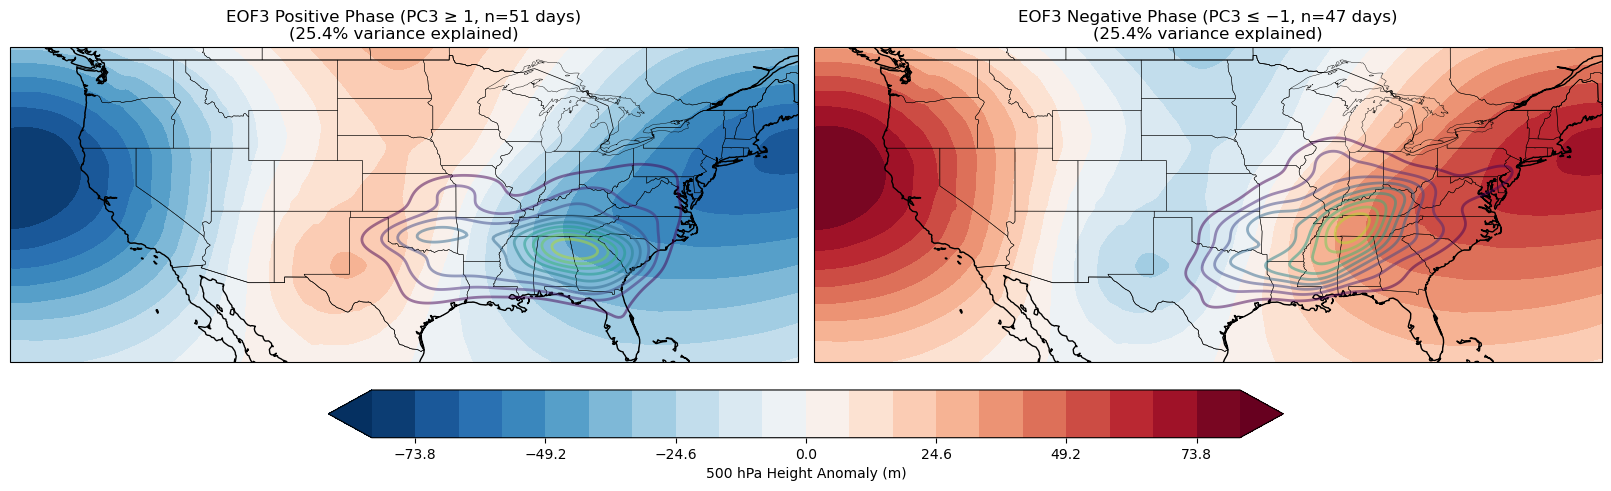

In [ ]:
event_colors = {
    'Tornado':           'red',
    'Hail':              'limegreen',
    'Thunderstorm Wind': 'dodgerblue',
}

vmax_d3 = np.max(np.abs(d3))
levels_d3 = np.linspace(-vmax_d3, vmax_d3, 21)

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

panels = [
    (axes[0], pos_reports, d3,
     f'EOF3 Positive Phase (PC3 ≥ 1, n={len(pos_dates)} days)', pos_pct),
    (axes[1], neg_reports, -d3,
     f'EOF3 Negative Phase (PC3 ≤ −1, n={len(neg_dates)} days)', neg_pct),
]

for ax, reports, pattern, title, pct_map in panels:
    cf = ax.contourf(
        lon, lat, pattern,
        levels=levels_d3, cmap='RdBu_r', extend='both',
        transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
    ax.add_feature(cfeature.STATES,  linewidth=0.3, edgecolor='black')
    ax.set_extent([-130, -67.5, 25, 50], crs=ccrs.PlateCarree())
    # for etype, color in event_colors.items():
    #     mask = reports['EVENT_TYPE'] == etype
    #     pct = pct_map.get(etype, 0)
    #     ax.scatter(
    #         reports.loc[mask, 'BEGIN_LON'],
    #         reports.loc[mask, 'BEGIN_LAT'],
    #         s=4, color=color, alpha=0.5,
    #         transform=ccrs.PlateCarree(),
    #         label=f'{etype} ({pct:.1f}%)', zorder=5
    #     )
    lon_grid = np.linspace(-125,-67,300)
    lat_grid = np.linspace(25,55,200)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
    grid_pts = np.vstack([lon_mesh.ravel(), lat_mesh.ravel()])

    pts = reports[['BEGIN_LON', 'BEGIN_LAT']].dropna().values
    kde = gaussian_kde(pts.T, bw_method=0.30) ## increase bw to smooth more, decrease to sharpen
    density = kde(grid_pts).reshape(lat_mesh.shape)

    threshold=0.0015
    levels = np.linspace(threshold, density.max(), 10)

    ax.contour(
        lon_mesh, lat_mesh, density,
        levels=levels,
        cmap='viridis', alpha=0.5,
        linewidths=2.0,
        transform = ccrs.PlateCarree(),
        zorder=5
    )


    ax.set_title(f'{title}\n({pve2[2]:.1f}% variance explained)')
    #ax.legend(loc='lower left', markerscale=3, fontsize=8)

cbar = fig.colorbar(
    cf, ax=axes,
    orientation='horizontal', pad=0.05, shrink=0.6
)
cbar.set_label('500 hPa Height Anomaly (m)')
fig.savefig('EOF3_storm_reports_by_phase(2)', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

In [105]:
print(f"min: {density.min():.6f}")
print(f"max: {density.max():.6f}")
print(f"80th pct: {np.percentile(density, 80):.6f}")
print(f"95th pct: {np.percentile(density, 95):.6f}")

min: 0.000000
max: 0.010844
80th pct: 0.000361
95th pct: 0.004070


## Regular compositing

#### Geopotential Height

In [10]:
def extract_era5_data(var, level=None):
    
    ## Define spatial bounding box
    lat_min, lat_max = 10, 75
    lon_min, lon_max = -140, -40
    
    # Load in ERA5 data
    outbreak_days["Year"] = outbreak_days["ERA5_time"].dt.year

    extracted_grids=[]
    
    for year, group in outbreak_days.groupby("Year"):
        if level is not None:
            file_path = f"/data1/ERA5/{var}/{var}_{year}.grib"
            open_kwargs = {"filter_by_keys": {"typeOfLevel": "isobaricInhPa"}}
        else:
            file_path = f"/data1/ERA5/surface/{var}/{var}_{year}.grib"
            open_kwargs = {}
    
        if not os.path.exists(file_path):
            print(f"File missing: {file_path}")
            continue
    
        print(f"Processing year {year}...")
    
        ds = xr.open_dataset(file_path, engine="cfgrib",
                             backend_kwargs=open_kwargs)
    
        ## extract the specific times for this year's outbreaks:
        times_to_extract = group["ERA5_time"].values
    
        try:
            sel_kwargs = dict(
                time=times_to_extract,
                latitude=slice(lat_max, lat_min),
                longitude=slice(lon_min, lon_max)
            )
            if level is not None:
                sel_kwargs["isobaricInhPa"] = level
    
            subset = ds[var.lower()].sel(**sel_kwargs)
    
            ## Only load this subset into RAM
            subset = subset.compute()
    
            extracted_grids.append(subset)
    
        except KeyError as e:
            print(f"Error slicing data for {year}: {e}")
    
        ds.close()
    
    print("DONE!")
    return xr.concat(extracted_grids, dim='time')

In [ ]:
z_500_all_outbreaks = extract_era5_data('Z', level=500)

In [10]:
z_500_all_outbreaks = z_500_all_outbreaks / 9.80665

In [11]:
z_500_all_outbreaks

<xarray.DataArray 'z' (time: 300, latitude: 261, longitude: 401)> Size: 126MB
array([[[5296.9106, 5297.446 , 5298.007 , ..., 5286.3564, 5288.09  ,
         5289.747 ],
        [5298.491 , 5298.95  , 5299.4087, ..., 5284.5464, 5286.3564,
         5288.1157],
        [5300.2246, 5300.658 , 5301.015 , ..., 5282.9917, 5284.827 ,
         5286.6367],
        ...,
        [5834.7344, 5834.887 , 5835.1167, ..., 5876.7466, 5876.4663,
         5876.3643],
        [5834.9385, 5835.142 , 5835.4736, ..., 5876.288 , 5876.0073,
         5875.9053],
        [5835.1934, 5835.499 , 5835.882 , ..., 5875.88  , 5875.574 ,
         5875.472 ]],

       [[5152.414 , 5149.5845, 5146.7544, ..., 4840.33  , 4840.916 ,
         4841.5024],
        [5161.158 , 5158.354 , 5155.524 , ..., 4839.2847, 4839.769 ,
         4840.2534],
        [5170.1826, 5167.4805, 5164.727 , ..., 4838.52  , 4838.953 ,
         4839.3867],
...
        [5870.2974, 5870.17  , 5870.119 , ..., 5889.57  , 5889.3916,
         5889.366 ],
        [5869.635 , 5869.558 , 5869.558 , ..., 5889.57  , 5889.366 ,
         5889.366 ],
        [5869.023 , 5868.9717, 5868.997 , ..., 5889.519 , 5889.315 ,
         5889.264 ]],

       [[5311.89  , 5310.7686, 5309.6465, ..., 5152.6104, 5152.865 ,
         5153.0947],
        [5315.459 , 5314.2607, 5313.037 , ..., 5152.3555, 5152.5596,
         5152.7124],
        [5319.436 , 5318.161 , 5316.8613, ..., 5151.769 , 5151.9478,
         5152.1006],
        ...,
        [5818.5615, 5818.0264, 5817.4907, ..., 5874.5693, 5874.5693,
         5874.7227],
        [5819.2754, 5818.74  , 5818.179 , ..., 5875.2324, 5875.207 ,
         5875.36  ],
        [5819.9893, 5819.4536, 5818.893 , ..., 5875.7676, 5875.742 ,
         5875.8696]]], shape=(300, 261, 401), dtype=float32)
Coordinates:
  * time           (time) datetime64[ns] 2kB 1996-03-25 ... 2025-03-05T12:00:00
  * latitude       (latitude) float64 2kB 75.0 74.75 74.5 ... 10.5 10.25 10.0
  * longitude      (longitude) float64 3kB -140.0 -139.8 -139.5 ... -40.25 -40.0
    number         int64 8B 0
    step           timedelta64[ns] 8B 00:00:00
    isobaricInhPa  float64 8B 500.0
    valid_time     (time) datetime64[ns] 2kB 1996-03-25 ... 2025-03-05T12:00:00
Attributes: (12/31)
    GRIB_paramId:                             129
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      462240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           z
    GRIB_totalNumber:                         0
    GRIB_units:                               m**2 s**-2
    long_name:                                Geopotential
    units:                                    m**2 s**-2
    standard_name:                            geopotential

In [17]:
raw_composite = z_500_all_outbreaks.mean(dim='time')

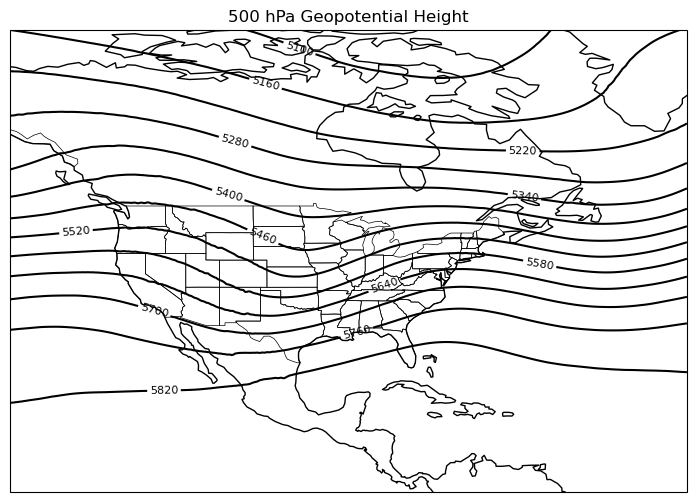

In [18]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

zlo = np.floor(np.nanmin(raw_composite) / 60) * 60
zhi = np.ceil(np.nanmax(raw_composite) / 60) * 60
levels_raw = np.arange(zlo, zhi + 1, 60)

cs = ax.contour(
    raw_composite.longitude,
    raw_composite.latitude,
    raw_composite,
    levels=levels_raw,
    colors='black',
    transform=ccrs.PlateCarree()
)
ax.clabel(cs, inline=True, fontsize=8, fmt='%d')


ax.coastlines()
ax.add_feature(cfeature.STATES, linewidth=0.5)

#plt.colorbar(cf, label="Geopotential height (m)")
plt.title("500 hPa Geopotential Height")
plt.show()

In [9]:
def compute_standardized_anomalies(
    data: xr.DataArray,
    var: str,
    climo_dir: str = "/data1/ERA5/daily_climo",
    level = None
) -> xr.DataArray:
    """
    Compute standardized anomalies for a given variable and dataset.

    Parameters
    ----------
    data : xr.DataArray
        Input data with a 'time' dimension (00z or 12z timestamps).
    var : str
        Variable name, e.g. 'tcwv' or 't2m'. Used to locate the climatology
        file at {climo_dir}/{var}_clim_{climo_years}.nc and to select the
        variables {var}_00z, {var}_std_00z, {var}_12z, {var}_std_12z.
    climo_dir : str
        Directory containing climatology files.

    Returns
    -------
    xr.DataArray
        Standardized anomalies concatenated along the 'time' dimension.
    """
    # Load climatology
    climo_path = f"{climo_dir}/{var}_clim_1996-2025.nc"
    climo = xr.open_dataset(climo_path)

    # Build mm-dd coordinate to replace integer doy
    dates_365 = pd.date_range(start="2023-01-01", end="2023-12-31")
    mm_dd_strings = dates_365.strftime("%m-%d")

    def _prep(da):
        da = da.assign_coords(doy=mm_dd_strings).rename({"doy": "month_day"})
        if var=='Z':
            da = da / 9.80665
        if level is not None:
            da = da.sel(level=level)
        return da

    climo_mean = {
        0:  _prep(climo[f"{var}_00z"]),
        12: _prep(climo[f"{var}_12z"]),
    }
    climo_std = {
        0:  _prep(climo[f"{var}_std_00z"]),
        12: _prep(climo[f"{var}_std_12z"]),
    }

    # Drop Feb 29 to align with 365-day climatology
    X = data.sel(
        time=~((data["time"].dt.month == 2) & (data["time"].dt.day == 29))
    )

    anoms_list = []
    for t in X.time.values:
        dt = pd.Timestamp(t)
        mm_dd = dt.strftime("%m-%d")
        hour = dt.hour

        mean_day = climo_mean[hour].sel(month_day=mm_dd)
        std_day  = climo_std[hour].sel(month_day=mm_dd)

        raw = X.sel(time=t)
        anom = (raw - mean_day) / std_day

        # Normalize time dimension: ensure exactly one length-1 time dim for concat
        if "time" in anom.dims:
            anom = anom.isel(time=0)
        if "time" in anom.dims and anom.sizes["time"] == 1:
            anom = anom.squeeze("time", drop=True)
        elif "time" in anom.coords:
            anom = anom.reset_coords("time", drop=True)

        anom = anom.expand_dims(time=[dt])
        anoms_list.append(anom)

    return xr.concat(anoms_list, dim="time")

In [13]:
z_500_anoms = compute_standardized_anomalies(z_500_all_outbreaks, var='Z', level=500)

/tmp/ipykernel_1699800/3926041548.py:79: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(anoms_list, dim="time")


In [14]:
composite = z_500_anoms.mean(dim='time')

In [15]:
composite

<xarray.DataArray (latitude: 261, longitude: 401)> Size: 419kB
array([[-0.10881372, -0.10863543, -0.1084493 , ...,  0.02727088,
         0.02778473,  0.02828941],
       [-0.10811779, -0.10791577, -0.10770322, ...,  0.02607431,
         0.02653868,  0.02700873],
       [-0.10727104, -0.10704038, -0.10681041, ...,  0.02489903,
         0.0253396 ,  0.02576506],
       ...,
       [-0.01209362, -0.0115751 , -0.01090351, ..., -0.10356194,
        -0.10186332, -0.10072535],
       [-0.01436236, -0.01359391, -0.01336218, ..., -0.10631037,
        -0.1044292 , -0.1031374 ],
       [-0.01780662, -0.01614749, -0.01570737, ..., -0.10928459,
        -0.10727473, -0.10548954]], shape=(261, 401), dtype=float32)
Coordinates:
  * latitude       (latitude) float64 2kB 75.0 74.75 74.5 ... 10.5 10.25 10.0
  * longitude      (longitude) float64 3kB -140.0 -139.8 -139.5 ... -40.25 -40.0
    number         int64 8B 0
    step           timedelta64[ns] 8B 00:00:00
    isobaricInhPa  float64 8B 500.0
    level          float64 8B 500.0
    n_years        int32 4B 30
Attributes: (12/31)
    GRIB_paramId:                             129
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      462240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           z
    GRIB_totalNumber:                         0
    GRIB_units:                               m**2 s**-2
    units:                                    m**2 s**-2
    standard_name:                            geopotential
    long_name:                                Daily climatological std dev of...

In [20]:
climo = xr.open_dataset('/data1/ERA5/daily_climo/Z_clim_1996-2025.nc')

(array([ 2724790., 18366339., 13996649., 15115889., 16675311., 17126867.,
        15213797., 14762689., 27690612., 27044657.]),
 array([48895.4296875 , 49849.1640625 , 50802.89453125, 51756.62890625,
        52710.36328125, 53664.09375   , 54617.828125  , 55571.5625    ,
        56525.296875  , 57479.02734375, 58432.76171875]),
 <BarContainer object of 10 artists>)

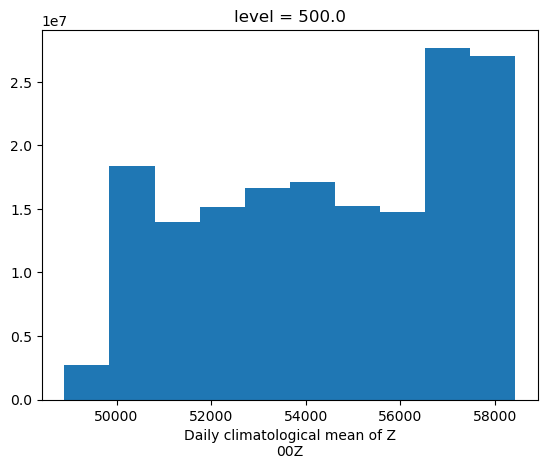

In [34]:
climo['Z_00z'].sel(level=500).plot()

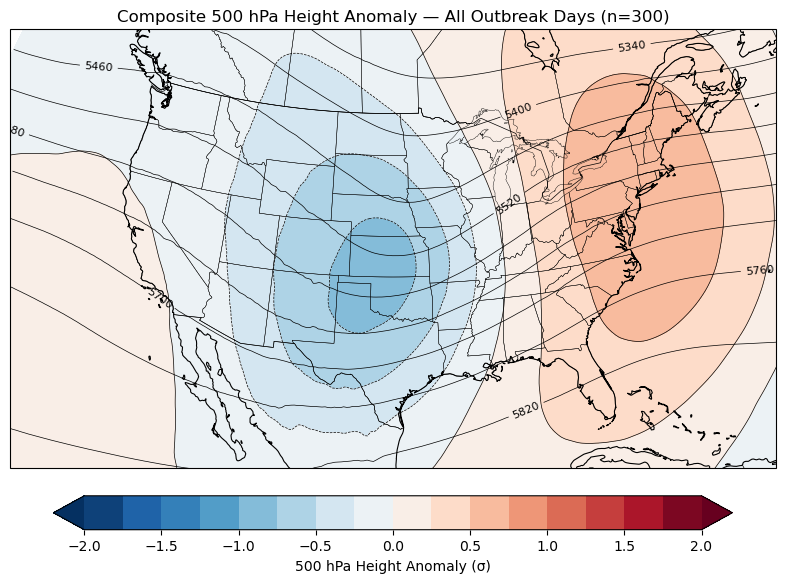

In [20]:
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-98, central_latitude=39
    )}
)

ax.set_extent([-128, -68, 23, 52], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)

levels = np.arange(-2, 2.1, 0.25)
cf = ax.contourf(
    composite.longitude, composite.latitude, composite,
    levels=levels,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    extend='both'
)
cs = ax.contour(
    composite.longitude, composite.latitude, composite,
    levels=levels,
    colors='k',
    linewidths=0.5,
    transform=ccrs.PlateCarree()
)
zlo = np.floor(np.nanmin(raw_composite) / 60) * 60
zhi = np.ceil(np.nanmax(raw_composite) / 60) * 60
levels_raw = np.arange(zlo, zhi + 1, 60)
cs2 = ax.contour(
    raw_composite.longitude,
    raw_composite.latitude,
    raw_composite,
    levels=levels_raw,
    colors='black',
    linewidths=0.5,
    transform=ccrs.PlateCarree()
)
ax.clabel(cs2, inline=True, fontsize=8, fmt='%d')

plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7,
             label='500 hPa Height Anomaly (σ)')
ax.set_title(f'Composite 500 hPa Height Anomaly — All Outbreak Days (n={len(z_500_all_outbreaks.time)})', 
             fontsize=12)

plt.tight_layout()
#plt.savefig('composite_all_outbreaks.png', dpi=150, bbox_inches='tight')
plt.show()

#### Specific Humidity (q):

In [28]:
q_850_all_outbreaks = extract_era5_data('q', level=850)

Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...
DONE!


In [29]:
q_composite_raw = q_850_all_outbreaks.mean(dim='time')

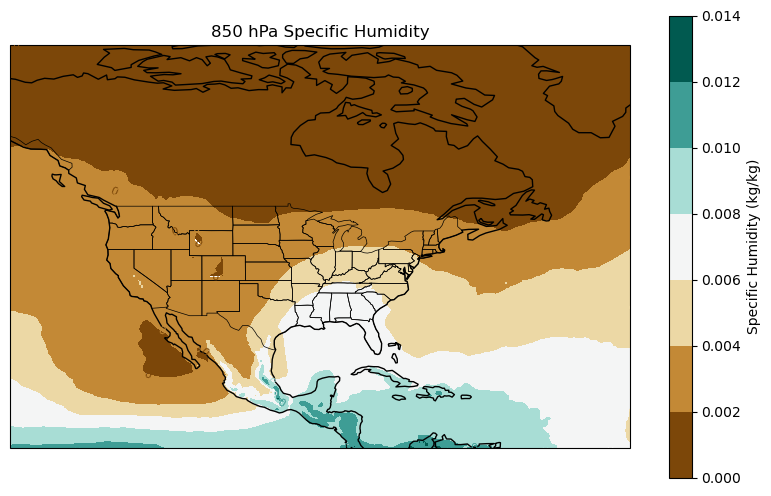

In [31]:
## Quick plot of the raw (not standardized) composite
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

cs = ax.contourf(
    q_composite_raw.longitude,
    q_composite_raw.latitude,
    q_composite_raw,
    #levels=20,
    cmap='BrBG',
    transform=ccrs.PlateCarree()
)
ax.clabel(cs, inline=True, fontsize=8, fmt='%d')


ax.coastlines()
ax.add_feature(cfeature.STATES, linewidth=0.5)

plt.colorbar(cs, label="Specific Humidity (kg/kg)")
plt.title("850 hPa Specific Humidity")
plt.show()

In [32]:
q_anoms_standardized = compute_standardized_anomalies(q_850_all_outbreaks, var='q', level=850)

/tmp/ipykernel_1699800/3926041548.py:79: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(anoms_list, dim="time")


In [33]:
q_composite = q_anoms_standardized.mean(dim='time')

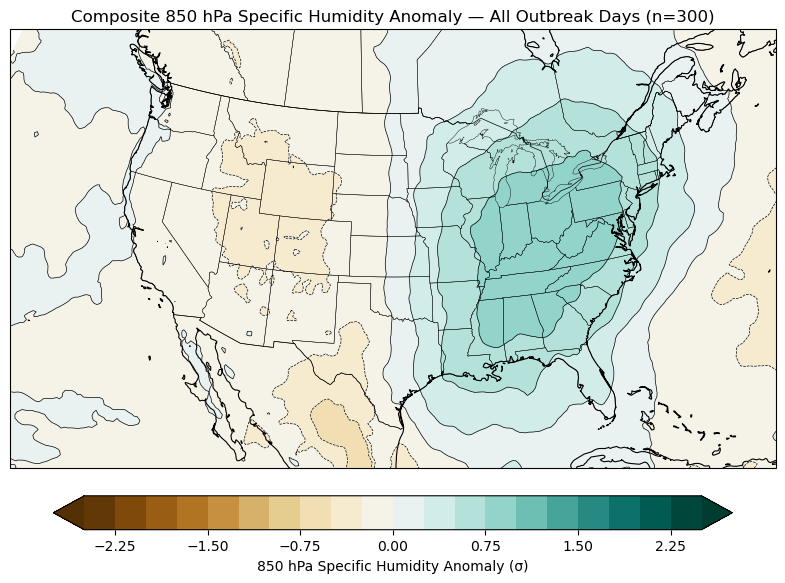

In [35]:
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-98, central_latitude=39
    )}
)

ax.set_extent([-128, -68, 23, 52], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)

levels = np.arange(-2.5, 2.6, 0.25)
cf = ax.contourf(
    q_composite.longitude, q_composite.latitude, q_composite,
    levels=levels,
    cmap='BrBG',
    transform=ccrs.PlateCarree(),
    extend='both'
)
cs = ax.contour(
    q_composite.longitude, q_composite.latitude, q_composite,
    levels=levels,
    colors='k',
    linewidths=0.5,
    transform=ccrs.PlateCarree()
)

plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7,
             label='850 hPa Specific Humidity Anomaly (σ)')
ax.set_title(f'Composite 850 hPa Specific Humidity Anomaly — All Outbreak Days (n={len(q_850_all_outbreaks.time)})', 
             fontsize=12)

plt.tight_layout()
#plt.savefig('q_composite_all_outbreaks.png', dpi=150, bbox_inches='tight')
plt.show()

#### 2m Temperature:

In [36]:
t2m_all_outbreaks = extract_era5_data('t2m')

Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...
DONE!


In [37]:
t2m_all_outbreaks

<xarray.DataArray 't2m' (time: 300, latitude: 261, longitude: 401)> Size: 126MB
array([[[260.80328, 260.73102, 260.64313, ..., 228.32866, 228.24272,
         228.21342],
        [260.95953, 260.87164, 260.7818 , ..., 227.50444, 227.21147,
         226.9185 ],
        [260.9947 , 260.90485, 260.815  , ..., 226.72905, 226.43022,
         226.1314 ],
        ...,
        [299.2154 , 299.28766, 299.29742, ..., 298.23492, 298.23297,
         298.21344],
        [299.32086, 299.41852, 299.37555, ..., 298.32867, 298.32086,
         298.3365 ],
        [299.32867, 299.40485, 299.3814 , ..., 298.4439 , 298.44   ,
         298.44586]],

       [[246.66216, 246.58012, 246.49614, ..., 231.29497, 231.3438 ,
         231.40825],
        [246.96098, 246.8809 , 246.80083, ..., 231.17583, 231.21294,
         231.25005],
        [247.19536, 247.11333, 247.0313 , ..., 231.14653, 231.1856 ,
         231.2227 ],
...
        [297.94904, 297.9334 , 297.9803 , ..., 298.13458, 298.21075,
         298.23615],
        [298.076  , 298.08966, 298.14435, ..., 298.24786, 298.32404,
         298.3592 ],
        [298.19318, 298.24396, 298.2635 , ..., 298.36896, 298.44318,
         298.49786]],

       [[255.35104, 255.4194 , 255.45065, ..., 232.67917, 232.39401,
         232.13815],
        [255.16159, 255.15182, 255.14206, ..., 232.70065, 232.40573,
         232.11081],
        [254.83542, 254.82565, 254.81393, ..., 232.78854, 232.48972,
         232.18893],
        ...,
        [297.8823 , 297.8569 , 297.84128, ..., 297.30026, 297.28464,
         297.2241 ],
        [297.9448 , 297.894  , 297.86472, ..., 297.52878, 297.478  ,
         297.4116 ],
        [298.00143, 297.9487 , 297.90573, ..., 297.71432, 297.67917,
         297.62057]]], shape=(300, 261, 401), dtype=float32)
Coordinates:
  * time        (time) datetime64[ns] 2kB 1996-03-25 ... 2025-03-05T12:00:00
  * latitude    (latitude) float64 2kB 75.0 74.75 74.5 74.25 ... 10.5 10.25 10.0
  * longitude   (longitude) float64 3kB -140.0 -139.8 -139.5 ... -40.25 -40.0
    number      int64 8B 0
    step        timedelta64[ns] 8B 00:00:00
    surface     float64 8B 0.0
    valid_time  (time) datetime64[ns] 2kB 1996-03-25 ... 2025-03-05T12:00:00
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      462240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           2t
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown

In [39]:
t2m_composite = t2m_all_outbreaks.mean(dim='time')

In [41]:
t2m_composite = t2m_composite - 273.15

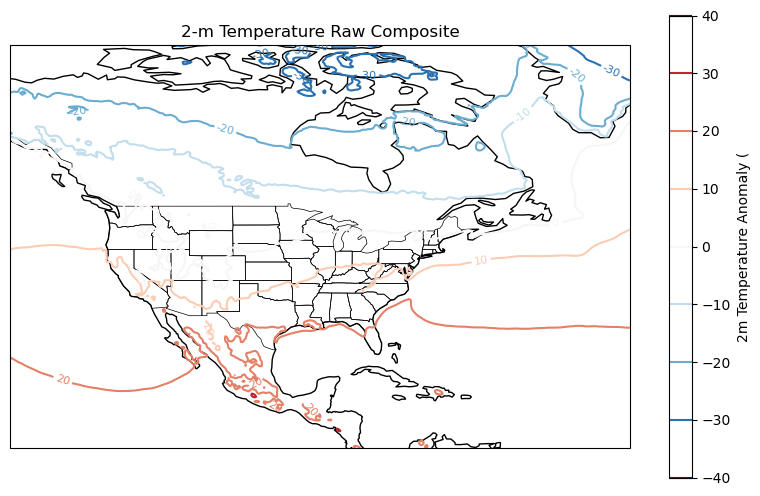

In [43]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

cs = ax.contour(
    t2m_composite.longitude,
    t2m_composite.latitude,
    t2m_composite,
    #levels=20,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree()
)
ax.clabel(cs, inline=True, fontsize=8, fmt='%d')


ax.coastlines()
ax.add_feature(cfeature.STATES, linewidth=0.5)

plt.colorbar(cs, label="2m Temperature Anomaly (")
plt.title("2-m Temperature Raw Composite")
plt.show()

In [44]:
t2m_anoms_standardized = compute_standardized_anomalies(t2m_all_outbreaks, var='t2m')

/tmp/ipykernel_1699800/3926041548.py:79: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(anoms_list, dim="time")


In [45]:
t2m_composite = t2m_anoms_standardized.mean(dim='time')

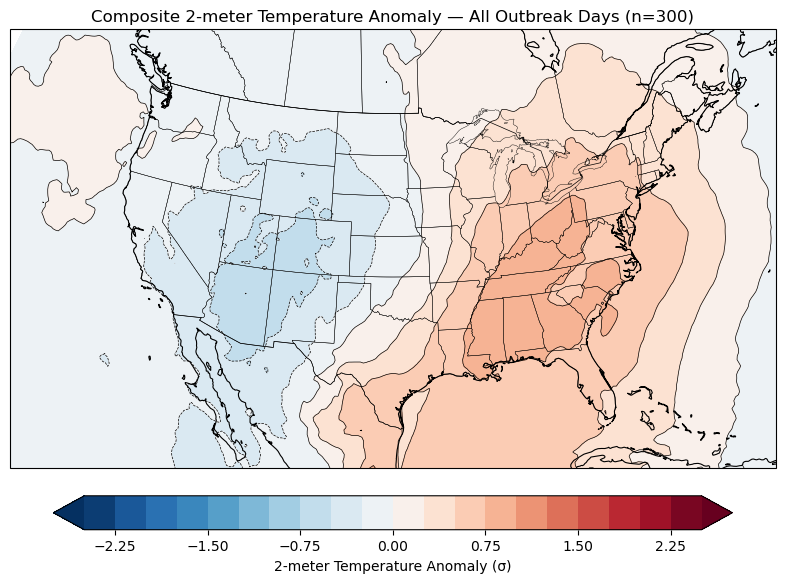

In [47]:
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-98, central_latitude=39
    )}
)

ax.set_extent([-128, -68, 23, 52], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)

levels = np.arange(-2.5, 2.75, 0.25)
cf = ax.contourf(
    t2m_composite.longitude, t2m_composite.latitude, t2m_composite,
    levels=levels,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree(),
    extend='both'
)
cs = ax.contour(
    t2m_composite.longitude, t2m_composite.latitude, t2m_composite,
    levels=levels,
    colors='k',
    linewidths=0.5,
    transform=ccrs.PlateCarree()
)

plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7,
             label='2-meter Temperature Anomaly (σ)')
ax.set_title(f'Composite 2-meter Temperature Anomaly — All Outbreak Days (n={len(t2m_all_outbreaks.time)})', 
             fontsize=12)

plt.tight_layout()
#plt.savefig('t2m_composite_all_outbreaks.png', dpi=150, bbox_inches='tight')
plt.show()

#### Total column water vapor (tcwv)

In [11]:
tcwv_all_outbreaks = extract_era5_data('tcwv')

Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...
DONE!


In [49]:
tcwv_all_outbreaks

<xarray.DataArray 'tcwv' (time: 300, latitude: 261, longitude: 401)> Size: 126MB
array([[[ 5.1702604 ,  5.2015104 ,  5.23862   , ...,  0.55502623,
          0.59604186,  0.6311981 ],
        [ 5.103854  ,  5.1702604 ,  5.23862   , ...,  0.43002623,
          0.47104186,  0.5140106 ],
        [ 5.023776  ,  5.0921354 ,  5.160495  , ...,  0.29916686,
          0.3421356 ,  0.38510436],
        ...,
        [40.29526   , 40.330418  , 40.30112   , ..., 27.865574  ,
         27.881199  , 27.943699  ],
        [41.873386  , 41.785496  , 41.648777  , ..., 27.86362   ,
         27.885105  , 27.951511  ],
        [44.12534   , 44.021824  , 43.82651   , ..., 27.818699  ,
         27.842136  , 27.836277  ]],

       [[ 1.1185551 ,  1.1380863 ,  1.1517582 , ...,  0.23964882,
          0.24160194,  0.2455082 ],
        [ 1.0970707 ,  1.0990238 ,  1.100977  , ...,  0.23183632,
          0.23378944,  0.23378944],
        [ 1.1087894 ,  1.1107426 ,  1.1126957 , ...,  0.22011757,
          0.2220707 ,  0.22402382],
...
        [34.313942  , 34.38816   , 34.370583  , ..., 31.58738   ,
         31.688942  , 31.802223  ],
        [35.11277   , 35.247536  , 35.370583  , ..., 32.0073    ,
         32.0698    , 32.145973  ],
        [35.94285   , 36.103004  , 36.31199   , ..., 32.30613   ,
         32.270973  , 32.253395  ]],

       [[ 3.137105  ,  3.0843706 ,  3.0257769 , ...,  0.699605  ,
          0.70546436,  0.7093706 ],
        [ 3.3831987 ,  3.3499956 ,  3.3167925 , ...,  0.68983936,
          0.69569874,  0.7015581 ],
        [ 3.4847612 ,  3.449605  ,  3.4164019 , ...,  0.68202686,
          0.68788624,  0.6937456 ],
        ...,
        [31.037495  , 31.199604  , 31.349995  , ..., 21.277729  ,
         21.187885  , 21.096088  ],
        [31.437885  , 31.605854  , 31.900776  , ..., 21.980854  ,
         21.887104  , 21.787495  ],
        [32.39101   , 32.52773   , 32.66054   , ..., 23.213276  ,
         23.211323  , 23.187885  ]]], shape=(300, 261, 401), dtype=float32)
Coordinates:
  * time        (time) datetime64[ns] 2kB 1996-03-25 ... 2025-03-05T12:00:00
  * latitude    (latitude) float64 2kB 75.0 74.75 74.5 74.25 ... 10.5 10.25 10.0
  * longitude   (longitude) float64 3kB -140.0 -139.8 -139.5 ... -40.25 -40.0
    number      int64 8B 0
    step        timedelta64[ns] 8B 00:00:00
    surface     float64 8B 0.0
    valid_time  (time) datetime64[ns] 2kB 1996-03-25 ... 2025-03-05T12:00:00
Attributes: (12/31)
    GRIB_paramId:                             137
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      462240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           tcwv
    GRIB_totalNumber:                         0
    GRIB_units:                               kg m**-2
    long_name:                                Total column vertically-integra...
    units:                                    kg m**-2
    standard_name:                            lwe_thickness_of_atmosphere_mas...

In [50]:
tcwv_composite = tcwv_all_outbreaks.mean(dim='time')

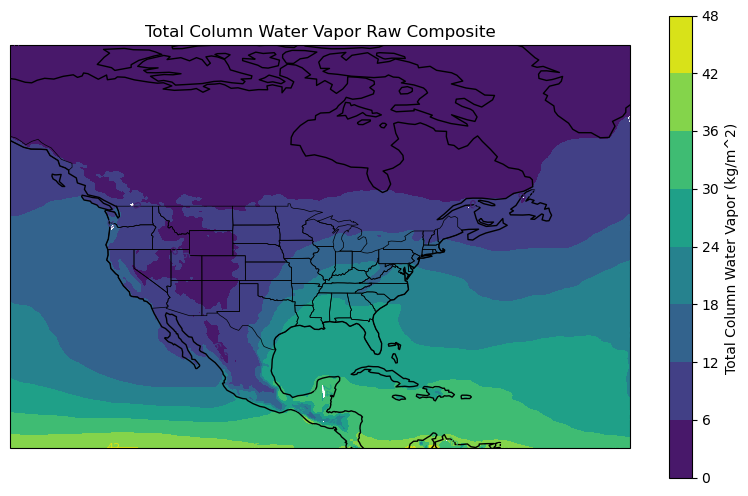

In [51]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

cs = ax.contourf(
    tcwv_composite.longitude,
    tcwv_composite.latitude,
    tcwv_composite,
    #levels=20,
    cmap='viridis',
    transform=ccrs.PlateCarree()
)
ax.clabel(cs, inline=True, fontsize=8, fmt='%d')


ax.coastlines()
ax.add_feature(cfeature.STATES, linewidth=0.5)

plt.colorbar(cs, label="Total Column Water Vapor (kg/m^2) ")
plt.title("Total Column Water Vapor Raw Composite")
plt.show()

In [12]:
tcwv_anoms = compute_standardized_anomalies(tcwv_all_outbreaks, var='tcwv')

/tmp/ipykernel_1702304/3926041548.py:79: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(anoms_list, dim="time")


In [13]:
tcwv_composite = tcwv_anoms.mean(dim='time')

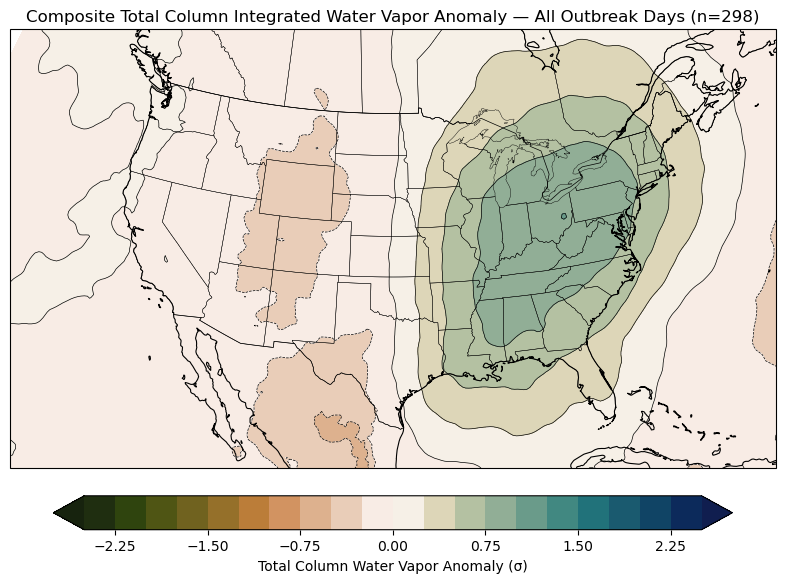

In [14]:
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-98, central_latitude=39
    )}
)

ax.set_extent([-128, -68, 23, 52], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)

levels = np.arange(-2.5, 2.75, 0.25)
cf = ax.contourf(
    tcwv_composite.longitude, tcwv_composite.latitude, tcwv_composite,
    levels=levels,
    #cmap='PuOr',
    cmap=cmocean.cm.tarn,
    transform=ccrs.PlateCarree(),
    extend='both'
)
cs = ax.contour(
    tcwv_composite.longitude, tcwv_composite.latitude, tcwv_composite,
    levels=levels,
    colors='k',
    linewidths=0.5,
    transform=ccrs.PlateCarree()
)

plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7,
             label='Total Column Water Vapor Anomaly (σ)')
ax.set_title(f'Composite Total Column Integrated Water Vapor Anomaly — All Outbreak Days (n={len(tcwv_anoms.time)})', 
             fontsize=12)

plt.tight_layout()
#plt.savefig('tcwv_composite_all_outbreaks.png', dpi=150, bbox_inches='tight')
plt.show()

#### 300 hPa V wind